# Scale Sweep Plotting
The goal of this file is to create visualizations for the scale sweep experiments to show the exploration behaviour at different scale magnitudes

## Setup
Specify folders, load data, add tags

In [1]:
# Dictionary of folder paths and relevant tags
superfolder_paths = [
    "experiments/20260320_ab_scalesweep_novar/model_name_gemini-3.1-flash-lite-preview",
    "experiments/20260320_ab_scalesweep_novar/model_name_Olmo-3.1-32B-Instruct",
    "experiments/20260320_ab_scalesweep_novar/model_name_Qwen3-32B",
    "experiments/20260320_farm_scalesweep_novar/model_name_gemini-3.1-flash-lite-preview",
    "experiments/20260320_farm_scalesweep_novar/model_name_Olmo-3.1-32B-Instruct",
    "experiments/20260320_farm_scalesweep_novar/model_name_Qwen3-32B",
    "experiments/20260320_clothing_scalesweep_novar/model_name_gemini-3.1-flash-lite-preview",
    "experiments/20260320_clothing_scalesweep_novar/model_name_Olmo-3.1-32B-Instruct",
    "experiments/20260320_clothing_scalesweep_novar/model_name_Qwen3-32B",
]

In [2]:
import os
os.chdir("../..")

### Function: map_sf_path_to_keys

This function takes a list of folder paths and maps each path to a dictionary containing the following keys:

- **domain**: Identifies the domain based on the folder path. If the path contains "farm", it is categorized as "Farm". If it contains "abandit" or "ab", it is categorized as "Bandit". Otherwise, it is labeled as "Unknown".
- **model**: Extracts the model name from the folder path. The model name is expected to follow the pattern `model_name_[model]`.
- **variance**: Determines the variance level based on the folder path. If the path contains "4sd_var", it is categorized as "High". If it contains "2sd_var", it is categorized as "Low". Otherwise, it is labeled as "No".
- **superfolder_path**: The original folder path is included for reference.

The function returns a pandas DataFrame with columns corresponding to these keys.

In [3]:
import re
import pandas as pd

def map_sf_paths_to_keys(folder_paths):
    data = []

    for folder_path in folder_paths:
        # Determine domain
        if "farm" in folder_path:
            domain = "Farm"
        elif "abandit" in folder_path or "ab" in folder_path:
            domain = "Bandit"
        elif "clothing" in folder_path or "rec" in folder_path:
            domain = "Clothing"
        else:
            domain = "Unknown"

        # Extract model
        model_match = re.search(r"model_name_(.+?)(?:_prompt_|$)", folder_path)
        model = model_match.group(1) if model_match else "Unknown"

        # Determine variance
        if "4sd_var" in folder_path:
            variance = "High"
        elif "2sd_var" in folder_path:
            variance = "Low"
        else:
            variance = "No"

        data.append({
            "domain": domain,
            "model": model,
            "variance": variance,
            "superfolder_path": folder_path
        })

    return pd.DataFrame(data)

## Data Loading

In [4]:
superdfs_tags_df = map_sf_paths_to_keys(superfolder_paths)

In [5]:
superdfs_tags_df

,domain,model,variance,superfolder_path
0,Bandit,gemini-3.1-flash-lite-preview,No,experiments/20260320_ab_scalesweep_novar/model...
1,Bandit,Olmo-3.1-32B-Instruct,No,experiments/20260320_ab_scalesweep_novar/model...
2,Bandit,Qwen3-32B,No,experiments/20260320_ab_scalesweep_novar/model...
3,Farm,gemini-3.1-flash-lite-preview,No,experiments/20260320_farm_scalesweep_novar/mod...
4,Farm,Olmo-3.1-32B-Instruct,No,experiments/20260320_farm_scalesweep_novar/mod...
5,Farm,Qwen3-32B,No,experiments/20260320_farm_scalesweep_novar/mod...
6,Clothing,gemini-3.1-flash-lite-preview,No,experiments/20260320_clothing_scalesweep_novar...
7,Clothing,Olmo-3.1-32B-Instruct,No,experiments/20260320_clothing_scalesweep_novar...
8,Clothing,Qwen3-32B,No,experiments/20260320_clothing_scalesweep_novar...


In [6]:
# Now we shift to creating a new Dataframe for all the semantic variation folders, including the scale and nomenclature tags

# Look for subdirectories within each superfolder.
# Extract scale values from subdirectory names matching the pattern `_scale[scale_value]`.
import os
import re

# Sorted longest-first to avoid partial matches (e.g. "sent_helpful" before "helpful")
NOMENCLATURES = sorted(
    ["alphanumeric", "sem_rel_helpful", "sem_rel_mislead", "sent_new_helpful", "sent_new_mislead",
     "sent_helpful", "sent_mislead", "ordinal_helpful", "ordinal_mislead", "world_helpful", "world_mislead"],
    key=len, reverse=True
)

semantic_variation_data = []

for _, row in superdfs_tags_df.iterrows():
    superfolder_path = row['superfolder_path']

    if os.path.exists(superfolder_path):
        subdirs = [d for d in os.listdir(superfolder_path) if os.path.isdir(os.path.join(superfolder_path, d))]

        for subdir in subdirs:
            # Extract scale value — supports negative values like _scale-0.5
            scale_match = re.search(r"_scale(-?[0-9\.]+)", subdir)
            if scale_match:
                scale_value = float(scale_match.group(1))

                # Extract nomenclature via longest-first substring matching
                nomenclature = "unknown"
                for nom in NOMENCLATURES:
                    if nom in subdir:
                        nomenclature = nom
                        break

                semantic_variation_data.append({
                    **row.to_dict(),
                    "scale": scale_value,
                    "nomenclature": nomenclature,
                    "semantic_folder": os.path.join(superfolder_path, subdir)
                })

# Create a new DataFrame for semantic variation folders
semantic_variation_df = pd.DataFrame(semantic_variation_data)

In [7]:
# Iterate through each semantic variation folder and find shuffle subfolders
import os
from glob import glob

replicate_data = []

for _, row in semantic_variation_df.iterrows():
    semantic_folder = row['semantic_folder']
    shuffle_folder = f"{semantic_folder}/shuffles"

    if os.path.exists(shuffle_folder):
        # Find all shuffle subfolders
        shuffle_paths = glob(f"{shuffle_folder}/shuffle_*")

        for shuffle_path in shuffle_paths:
            # Find all jsonl files in the shuffle folder
            jsonl_files = glob(f"{shuffle_path}/*.jsonl")

            # Sort files by modification time (most recent first)
            jsonl_files.sort(key=os.path.getmtime, reverse=True)

            for jsonl_file in jsonl_files:
                try:
                    # Read the jsonl file
                    df = pd.read_json(jsonl_file, lines=True)

                    # Record the number of rows in the file
                    row_count = len(df)
                    replicate_data.append({
                        **row.to_dict(),
                        "shuffle_number": os.path.basename(shuffle_path).split("_")[-1],
                        "jsonl_file": jsonl_file,
                        "row_count": row_count
                    })
                    break  # Only take the most recent valid file
                except Exception as e:
                    continue

# Create a new DataFrame for replicates
replicate_df = pd.DataFrame(replicate_data)
# replicate_df

## Old Visualization
Generate two kinds of plot. First, plot the mean steps to exploration for each scale value. Then, plot the distributions for each scale individually.

### Report distributional statistics
For each model, domain, and 

In [47]:
# Summary table: each row is a (model, domain, nomenclature, scale) combination
# Grouped by model > domain > nomenclature, scale sorted ascending
summary_df = (
    replicate_df
    .groupby(['model', 'domain', 'nomenclature', 'scale'], sort=False)
    .agg(
        n_replicates=('row_count', 'count'),
        median_turns=('row_count', 'median'),
        mean_turns=('row_count', 'mean'),
        prop_at_least_3=('row_count', lambda x: (x >= 3).mean()),
        prop_at_least_10=('row_count', lambda x: (x >= 10).mean()),
    )
    .reset_index()
    .sort_values(['model', 'domain', 'nomenclature', 'scale'], ascending=[True, True, True, True])
    .reset_index(drop=True)
)

summary_df['median_turns'] = summary_df['median_turns'].round(2)
summary_df['mean_turns'] = summary_df['mean_turns'].round(2)
summary_df['prop_at_least_3'] = summary_df['prop_at_least_3'].round(2)
summary_df['prop_at_least_10'] = summary_df['prop_at_least_10'].round(2)

print(summary_df.to_string(index=False))
print("\n--- LaTeX ---\n")
print(summary_df.to_latex(index=False, float_format="%.2f"))

KeyError: 'model'

### Distribution Plots

### Averaged Plot

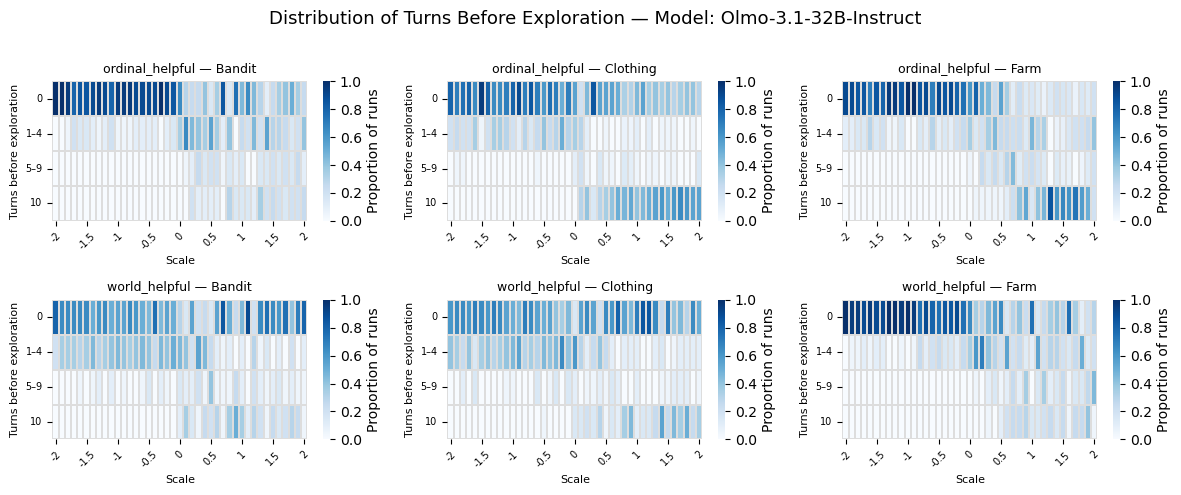

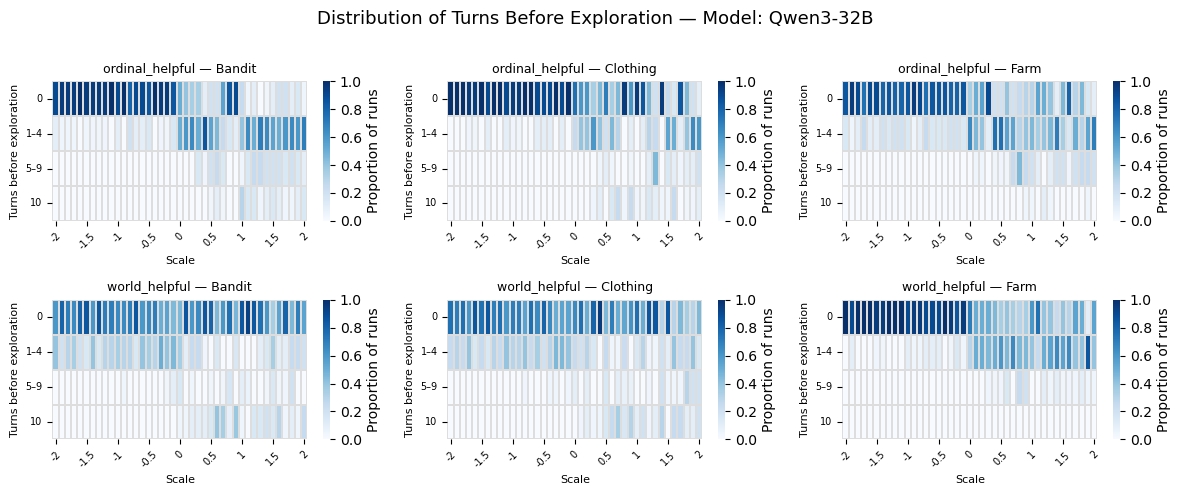

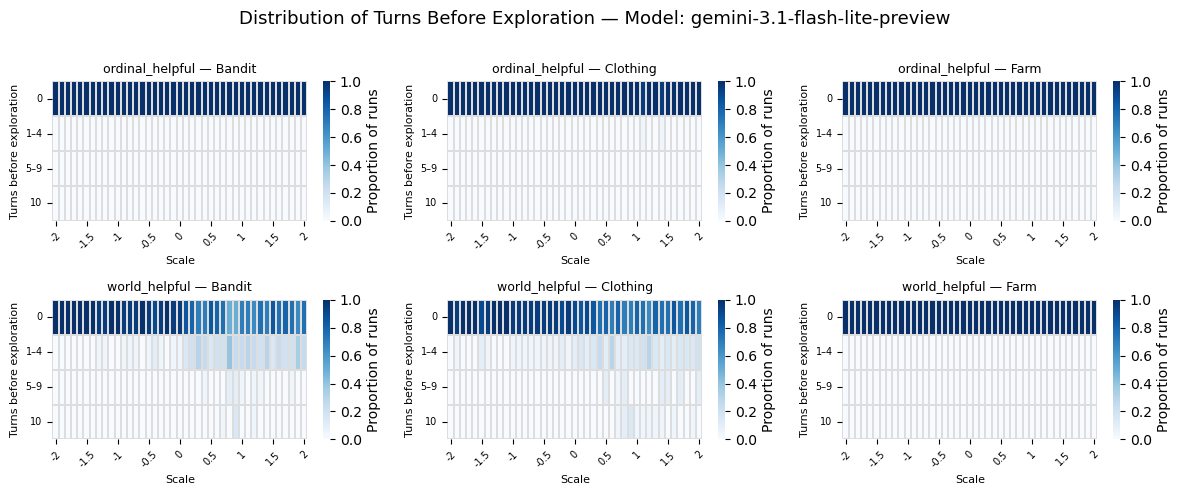

In [ ]:
# Distribution heatmap: proportion of runs per (turns × scale)
# Rows = nomenclature (ordinal/world helpful only), Columns = domain, one figure per model
import math
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

ROW_COUNT_CAP = 12
NOMS = ['ordinal_helpful', 'world_helpful']

# turns_before = row_count - 2 (row_count==2 → 0 turns before exploration)
# Bins: [0], [1–4], [5–9], [10]
BIN_LABELS = ['0', '1–4', '5–9', '10']

def assign_bin(turns):
    if turns == 0:     return '0'
    elif turns <= 4:   return '1–4'
    elif turns <= 9:   return '5–9'
    else:              return '10'

models  = sorted(replicate_df['model'].unique())
domains = sorted(replicate_df['domain'].unique())

for model in models:
    model_df = replicate_df[replicate_df['model'] == model].copy()
    model_df = model_df[model_df['nomenclature'].isin(NOMS)]
    model_df['row_count'] = model_df['row_count'].clip(upper=ROW_COUNT_CAP)
    model_df['turns_before'] = (model_df['row_count'] - 2).clip(lower=0)
    model_df['bin'] = model_df['turns_before'].apply(assign_bin)
    if model_df.empty:
        continue

    nrows = len(NOMS)
    ncols = len(domains)
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(4 * ncols, 2.5 * nrows),
        squeeze=False,
    )

    for row_idx, nom in enumerate(NOMS):
        for col_idx, domain in enumerate(domains):
            ax = axes[row_idx, col_idx]
            sub = model_df[(model_df['nomenclature'] == nom) & (model_df['domain'] == domain)].copy()

            if sub.empty:
                ax.set_visible(False)
                continue

            sub['scale'] = pd.to_numeric(sub['scale'])
            scales = sorted(sub['scale'].unique())

            # Build pivot: rows = bins, cols = scale, values = proportion
            pivot = pd.DataFrame(0.0, index=BIN_LABELS, columns=scales)
            for scale in scales:
                counts = sub[sub['scale'] == scale]['bin'].value_counts()
                total = counts.sum()
                for b in BIN_LABELS:
                    pivot.loc[b, scale] = counts.get(b, 0) / total if total > 0 else 0.0

            sns.heatmap(
                pivot, ax=ax,
                cmap='Blues', vmin=0, vmax=1,
                annot=False,
                linewidths=0.3, linecolor='#dddddd',
                cbar=False,
            )
            ax.set_title(f"{nom} — {domain}", fontsize=13)
            ax.set_xlabel('Scale', fontsize=8)
            ax.set_ylabel('Turns before exploration', fontsize=8)

            # X-axis ticks every 0.5
            all_scales = np.array(scales, dtype=float)
            scale_min, scale_max = all_scales.min(), all_scales.max()
            tick_vals = np.arange(math.ceil(scale_min * 2) / 2, scale_max + 0.01, 0.5)
            # Map tick values to heatmap x positions (column indices)
            tick_positions = [np.searchsorted(all_scales, t) for t in tick_vals if t in all_scales or any(np.isclose(all_scales, t))]
            tick_labels    = [f'{t:g}' for t in tick_vals if t in all_scales or any(np.isclose(all_scales, t))]
            ax.set_xticks([p + 0.5 for p in tick_positions])
            ax.set_xticklabels(tick_labels, rotation=45, fontsize=7)
            ax.tick_params(axis='y', labelrotation=0, labelsize=7)

    # Shared colorbar
    import matplotlib as mpl
    sm = mpl.cm.ScalarMappable(cmap='Blues', norm=mpl.colors.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02)
    cbar.set_label('Proportion of runs', fontsize=11)

    plt.suptitle(f"Distribution of Turns Before Exploration — Model: {model}", fontsize=17)
    plt.tight_layout(rect=[0, 0, 0.92, 0.97])
    plt.show()

### Median Turns to First Exploration by Scale
One figure: rows = models, columns = domains. X = scale, Y = median(row_count − 1). Lines = nomenclature.

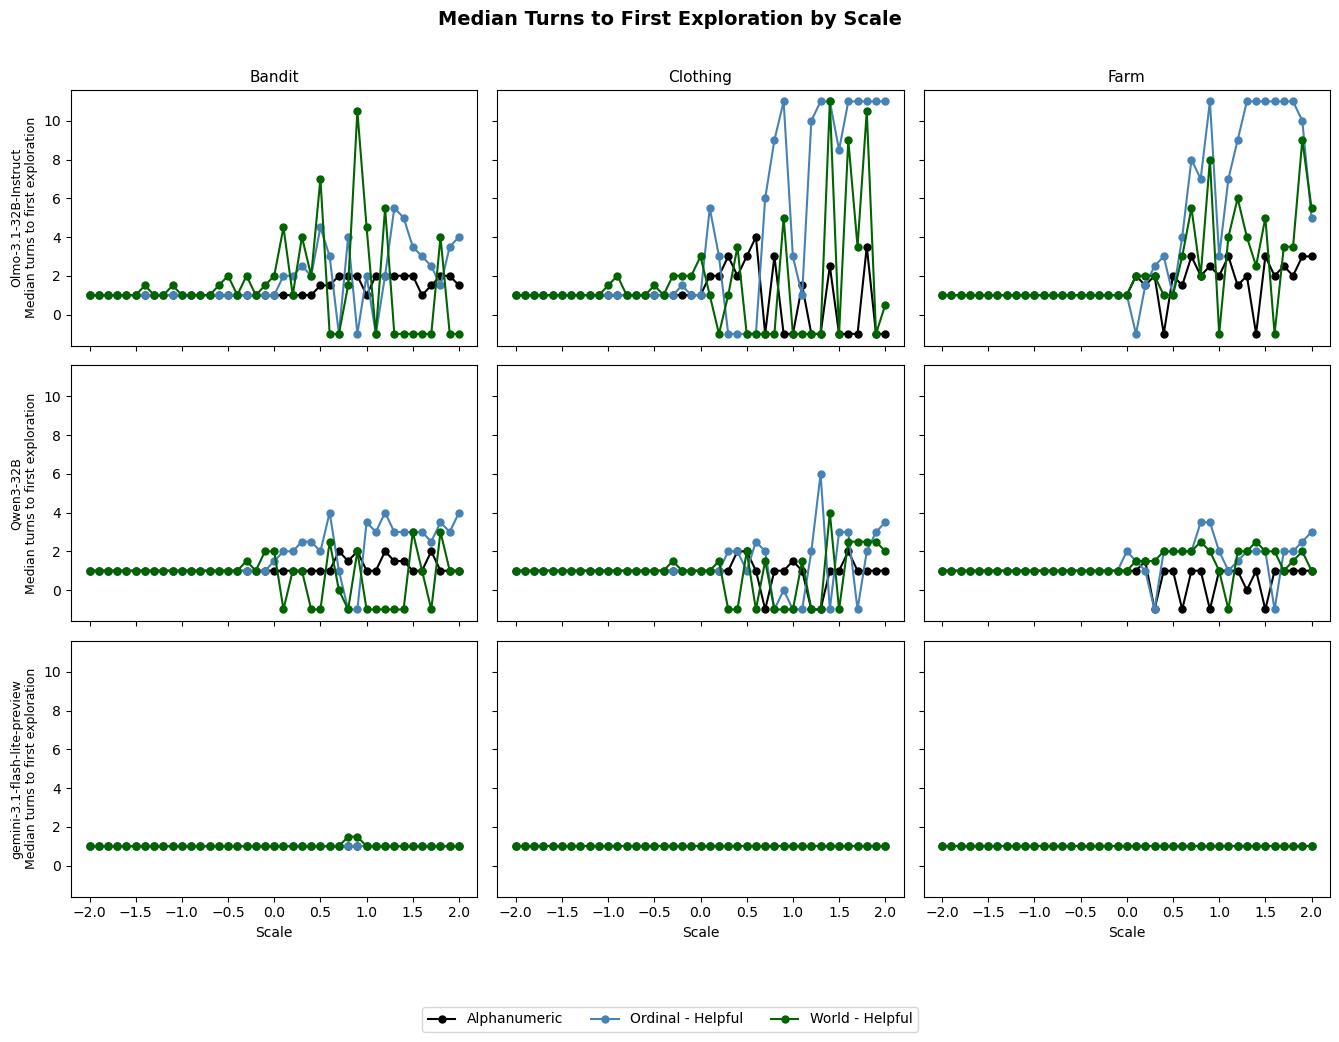

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Style constants (matching label_channel_bias.ipynb) ──────────────────────
NOM_STYLES = {
    'alphanumeric':    {'color': 'black',         'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful': {'color': 'steelblue',      'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead': {'color': 'cornflowerblue', 'linestyle': ':',  'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_helpful':   {'color': 'darkgreen',      'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':   {'color': 'mediumseagreen', 'linestyle': ':',  'marker': '^', 'label': 'World - Misleading'},
}

NOMS_TO_PLOT = ['alphanumeric', 'ordinal_helpful', 'ordinal_mislead', 'world_helpful', 'world_mislead']
LEGEND_ORDER = NOMS_TO_PLOT

# ── Compute per-(model, domain, nomenclature, scale) medians ─────────────────
plot_df = (
    replicate_df[replicate_df['nomenclature'].isin(NOMS_TO_PLOT)]
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .agg(median_first_explor=('row_count', lambda x: x.median() - 1))
    .reset_index()
)

models  = sorted(plot_df['model'].unique())
domains = sorted(plot_df['domain'].unique())

nrows = len(models)
ncols = len(domains)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(4.5 * ncols, 3.5 * nrows),
    sharex=True, sharey=True,
    squeeze=False,
)

label_to_handle = {}

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df['model'] == model) & (plot_df['domain'] == domain)]

        for nom in NOMS_TO_PLOT:
            nom_sub = sub[sub['nomenclature'] == nom].sort_values('scale')
            if nom_sub.empty:
                continue
            style = NOM_STYLES[nom]
            handle, = ax.plot(
                nom_sub['scale'], nom_sub['median_first_explor'],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], label=style['label'],
                markersize=5, linewidth=1.5,
            )
            if style['label'] not in label_to_handle:
                label_to_handle[style['label']] = handle

        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nMedian turns to first exploration", fontsize=9)
        if row_idx == nrows - 1:
            ax.set_xlabel("Scale", fontsize=10)

# ── Shared legend at bottom ───────────────────────────────────────────────────
sorted_labels  = [NOM_STYLES[k]['label'] for k in LEGEND_ORDER if NOM_STYLES[k]['label'] in label_to_handle]
sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]

fig.legend(
    sorted_handles, sorted_labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
)

fig.suptitle("Median Turns to First Exploration by Scale", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()

### Mean Turns to First Exploration by Scale
One figure: rows = models, columns = domains. X = scale, Y = mean(row_count − 1). Lines = nomenclature.

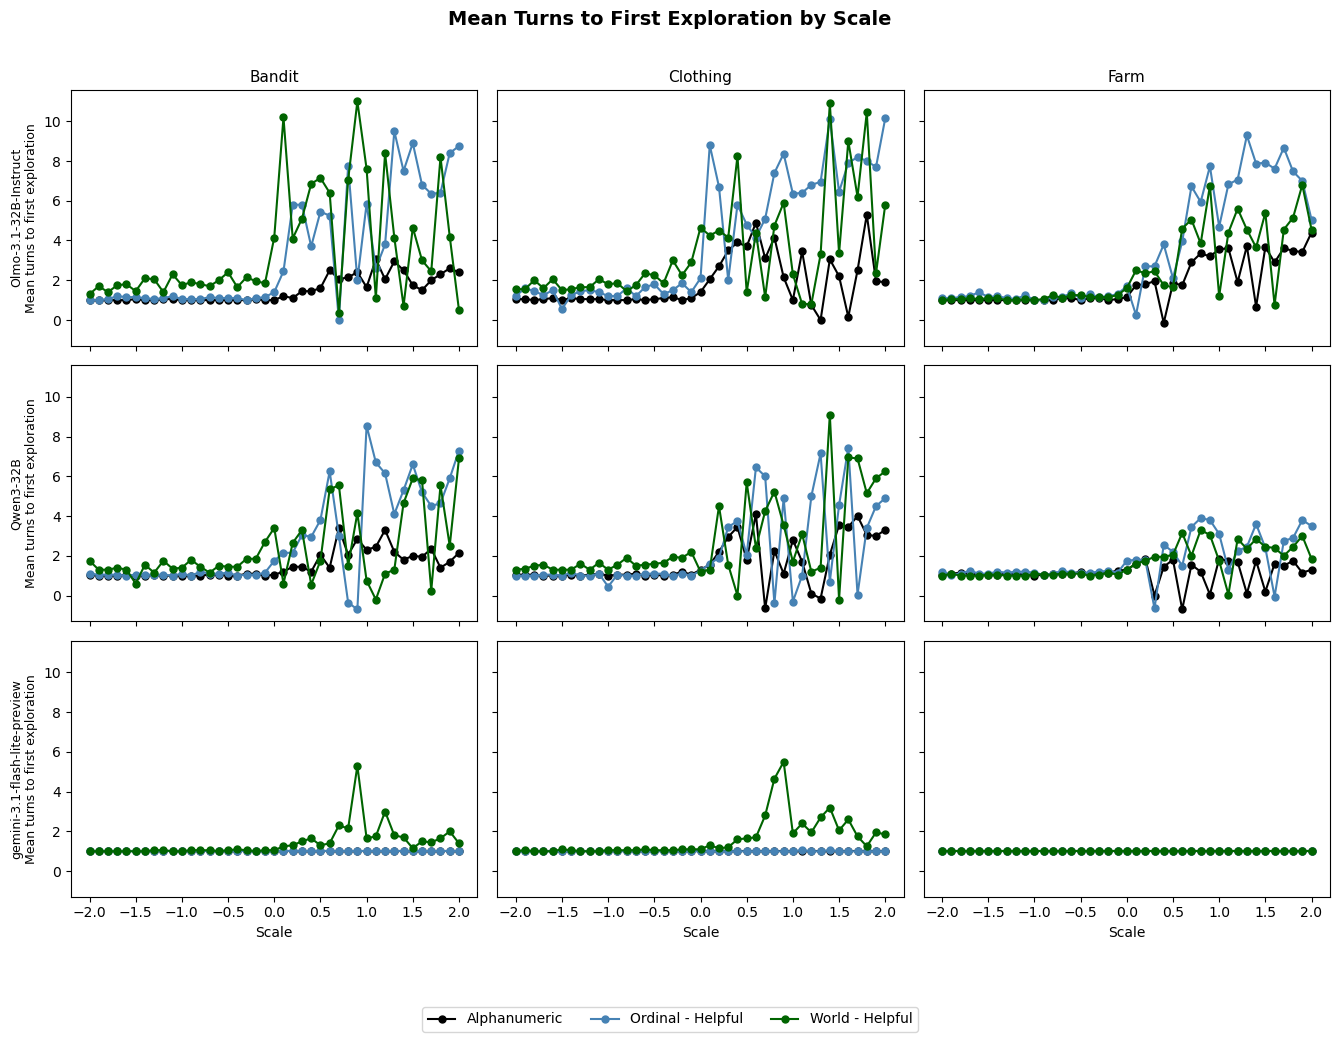

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Style constants (matching label_channel_bias.ipynb) ──────────────────────
NOM_STYLES = {
    'alphanumeric':    {'color': 'black',         'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful': {'color': 'steelblue',      'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead': {'color': 'cornflowerblue', 'linestyle': ':',  'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_helpful':   {'color': 'darkgreen',      'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':   {'color': 'mediumseagreen', 'linestyle': ':',  'marker': '^', 'label': 'World - Misleading'},
}

NOMS_TO_PLOT = ['alphanumeric', 'ordinal_helpful', 'ordinal_mislead', 'world_helpful', 'world_mislead']
LEGEND_ORDER = NOMS_TO_PLOT

# ── Compute per-(model, domain, nomenclature, scale) means ───────────────────
plot_df = (
    replicate_df[replicate_df['nomenclature'].isin(NOMS_TO_PLOT)]
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .agg(mean_first_explor=('row_count', lambda x: x.mean() - 1))
    .reset_index()
)

models  = sorted(plot_df['model'].unique())
domains = sorted(plot_df['domain'].unique())

nrows = len(models)
ncols = len(domains)

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(4.5 * ncols, 3.5 * nrows),
    sharex=True, sharey=True,
    squeeze=False,
)

label_to_handle = {}

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df['model'] == model) & (plot_df['domain'] == domain)]

        for nom in NOMS_TO_PLOT:
            nom_sub = sub[sub['nomenclature'] == nom].sort_values('scale')
            if nom_sub.empty:
                continue
            style = NOM_STYLES[nom]
            handle, = ax.plot(
                nom_sub['scale'], nom_sub['mean_first_explor'],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], label=style['label'],
                markersize=5, linewidth=1.5,
            )
            if style['label'] not in label_to_handle:
                label_to_handle[style['label']] = handle

        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nMean turns to first exploration", fontsize=9)
        if row_idx == nrows - 1:
            ax.set_xlabel("Scale", fontsize=10)

# ── Shared legend at bottom ───────────────────────────────────────────────────
sorted_labels  = [NOM_STYLES[k]['label'] for k in LEGEND_ORDER if NOM_STYLES[k]['label'] in label_to_handle]
sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]

fig.legend(
    sorted_handles, sorted_labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
)

fig.suptitle("Mean Turns to First Exploration by Scale", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()

### Proportion of Runs Without Exploration in First 5 Turns
One figure: rows = models, columns = domains. X = scale, Y = P(row_count > 5). Lines = nomenclature.

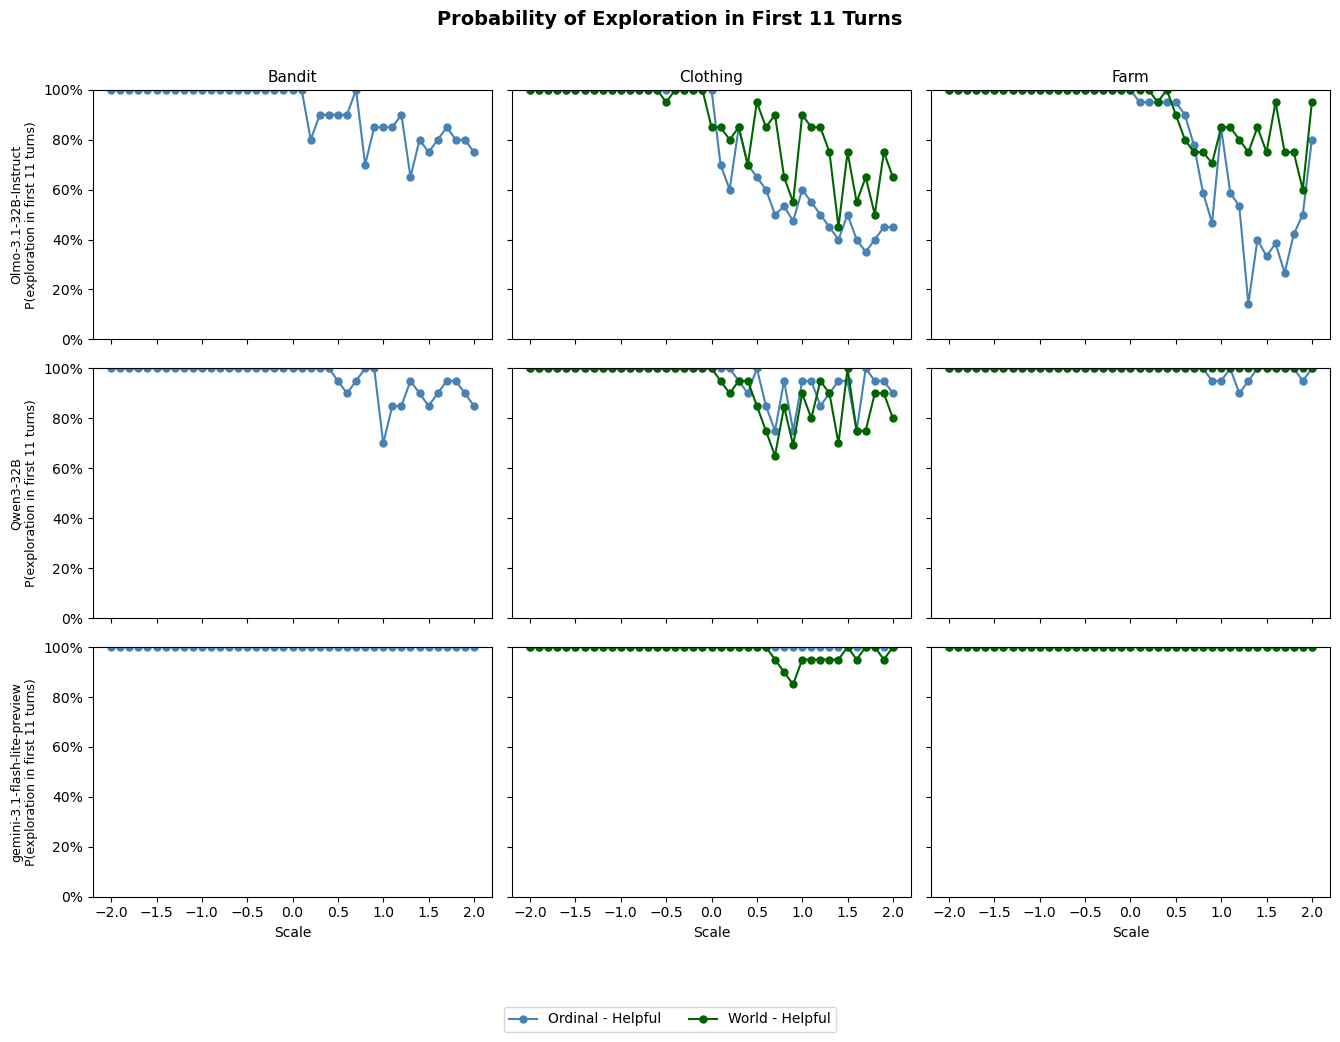

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXPLORATION_THRESHOLD = 11

NOM_STYLES = {
    'alphanumeric':    {'color': 'black',         'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful': {'color': 'steelblue',      'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead': {'color': 'cornflowerblue', 'linestyle': ':',  'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_helpful':   {'color': 'darkgreen',      'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':   {'color': 'mediumseagreen', 'linestyle': ':',  'marker': '^', 'label': 'World - Misleading'},
}

BANDIT_NOMS = ['ordinal_helpful']
OTHER_NOMS  = ['ordinal_helpful', 'world_helpful']
ALL_NOMS    = list(dict.fromkeys(BANDIT_NOMS + OTHER_NOMS))
LEGEND_ORDER = ALL_NOMS

plot_df = (
    replicate_df[replicate_df['nomenclature'].isin(ALL_NOMS)]
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .agg(prob_explor=('row_count', lambda x: 1 - (x > EXPLORATION_THRESHOLD).mean()))
    .reset_index()
)

models  = sorted(plot_df['model'].unique())
domains = sorted(plot_df['domain'].unique())

fig, axes = plt.subplots(
    nrows=len(models), ncols=len(domains),
    figsize=(4.5 * len(domains), 3.5 * len(models)),
    sharex=True, sharey=True,
    squeeze=False,
)

label_to_handle = {}

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df['model'] == model) & (plot_df['domain'] == domain)]
        noms = BANDIT_NOMS if domain == 'Bandit' else OTHER_NOMS

        for nom in noms:
            nom_sub = sub[sub['nomenclature'] == nom].sort_values('scale')
            if nom_sub.empty:
                continue
            style = NOM_STYLES[nom]
            handle, = ax.plot(
                nom_sub['scale'], nom_sub['prob_explor'],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], label=style['label'],
                markersize=5, linewidth=1.5,
            )
            if style['label'] not in label_to_handle:
                label_to_handle[style['label']] = handle

        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nP(exploration in first {EXPLORATION_THRESHOLD} turns)", fontsize=9)
        if row_idx == len(models) - 1:
            ax.set_xlabel("Scale", fontsize=10)

sorted_labels  = [NOM_STYLES[k]['label'] for k in LEGEND_ORDER if NOM_STYLES[k]['label'] in label_to_handle]
sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]

fig.legend(
    sorted_handles, sorted_labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
)

fig.suptitle(f"Probability of Exploration in First {EXPLORATION_THRESHOLD} Turns", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()

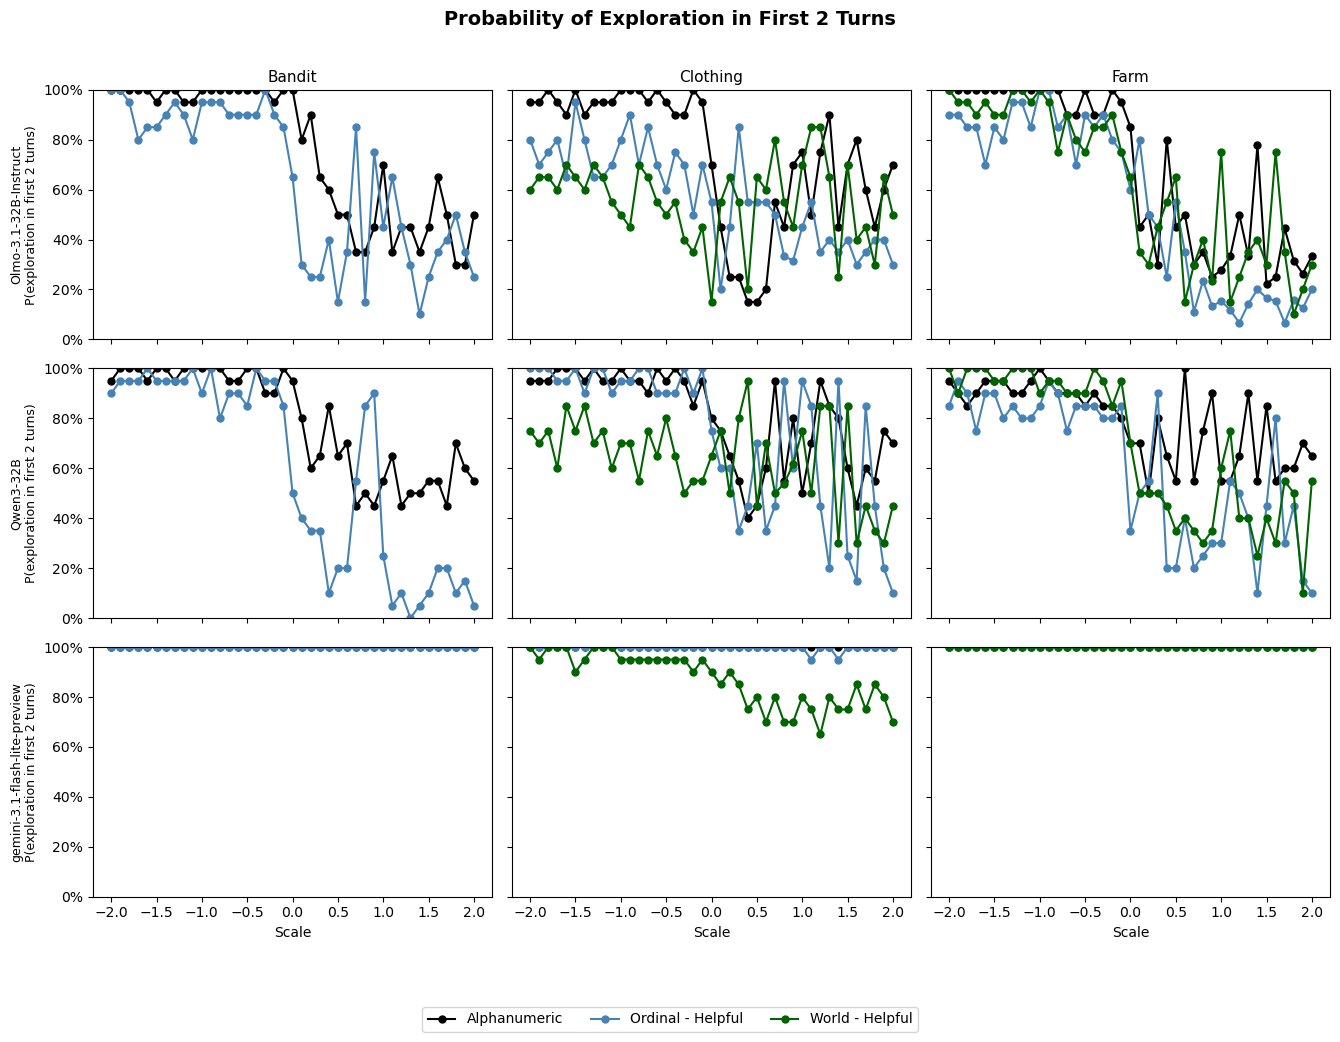

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXPLORATION_THRESHOLD = 2

NOM_STYLES = {
    'alphanumeric':    {'color': 'black',         'linestyle': '-',  'marker': 'o', 'label': 'Alphanumeric'},
    'ordinal_helpful': {'color': 'steelblue',      'linestyle': '-',  'marker': 'o', 'label': 'Ordinal - Helpful'},
    'ordinal_mislead': {'color': 'cornflowerblue', 'linestyle': ':',  'marker': '^', 'label': 'Ordinal - Misleading'},
    'world_helpful':   {'color': 'darkgreen',      'linestyle': '-',  'marker': 'o', 'label': 'World - Helpful'},
    'world_mislead':   {'color': 'mediumseagreen', 'linestyle': ':',  'marker': '^', 'label': 'World - Misleading'},
}

BANDIT_NOMS = ['alphanumeric', 'ordinal_helpful']
OTHER_NOMS  = ['alphanumeric', 'ordinal_helpful', 'world_helpful']
ALL_NOMS    = list(dict.fromkeys(BANDIT_NOMS + OTHER_NOMS))
LEGEND_ORDER = ALL_NOMS

plot_df = (
    replicate_df[replicate_df['nomenclature'].isin(ALL_NOMS)]
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .agg(prob_explor=('row_count', lambda x: 1 - (x > EXPLORATION_THRESHOLD).mean()))
    .reset_index()
)

models  = sorted(plot_df['model'].unique())
domains = sorted(plot_df['domain'].unique())

fig, axes = plt.subplots(
    nrows=len(models), ncols=len(domains),
    figsize=(4.5 * len(domains), 3.5 * len(models)),
    sharex=True, sharey=True,
    squeeze=False,
)

label_to_handle = {}

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = plot_df[(plot_df['model'] == model) & (plot_df['domain'] == domain)]
        noms = BANDIT_NOMS if domain == 'Bandit' else OTHER_NOMS

        for nom in noms:
            nom_sub = sub[sub['nomenclature'] == nom].sort_values('scale')
            if nom_sub.empty:
                continue
            style = NOM_STYLES[nom]
            handle, = ax.plot(
                nom_sub['scale'], nom_sub['prob_explor'],
                color=style['color'], linestyle=style['linestyle'],
                marker=style['marker'], label=style['label'],
                markersize=5, linewidth=1.5,
            )
            if style['label'] not in label_to_handle:
                label_to_handle[style['label']] = handle

        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nP(exploration in first {EXPLORATION_THRESHOLD} turns)", fontsize=9)
        if row_idx == len(models) - 1:
            ax.set_xlabel("Scale", fontsize=10)

sorted_labels  = [NOM_STYLES[k]['label'] for k in LEGEND_ORDER if NOM_STYLES[k]['label'] in label_to_handle]
sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]

fig.legend(
    sorted_handles, sorted_labels,
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=len(sorted_handles), borderaxespad=0.5, frameon=True, fontsize=10,
)

fig.suptitle(f"Probability of Exploration in First {EXPLORATION_THRESHOLD} Turns", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()

## P(Y=0 | X=x) and E[Y | Y>0, X=x]

For each observed reward value x (the scale parameter):
- **P(Y=0 | X=x)**: probability the agent explores immediately on the next turn
- **E[Y | Y>0, X=x]**: expected turns before exploration, *given* the agent did not explore immediately (NaN when all 20 runs had Y=0)

One figure per model; rows = nomenclature, columns = domain.  
Dashed lines mark the hypothesised threshold locations x=0 and x=1.0.

In [8]:
import numpy as np
import pandas as pd

NOMS_TO_PLOT = ['alphanumeric', 'ordinal_helpful', 'world_helpful']
NOM_LABELS = {
    'alphanumeric':    'Alphanumeric',
    'ordinal_helpful': 'Ordinal \u2013 Helpful',
    'world_helpful':   'World \u2013 Helpful',
}

# Y = row_count - 2, capped at 10: Y=0 means the agent explored on the very next turn
# (consistent with cell 17 convention: row_count==2 → 0 turns before exploration)
# Y=10 means the agent never explored within the horizon (hit the cap)
_stats = replicate_df[replicate_df['nomenclature'].isin(NOMS_TO_PLOT)].copy()
_stats['Y'] = (_stats['row_count'] - 2).clip(lower=0, upper=10)

def _compute_stats(group):
    Y       = group['Y']
    p_y0    = float((Y == 0).mean())
    p_y10   = float((Y >= 10).mean())
    y_pos   = Y[Y > 0]
    e_y_pos = float(y_pos.mean()) if len(y_pos) > 0 else float('nan')
    return pd.Series({
        'P_Y0':    p_y0,
        'P_Y10':   p_y10,
        'E_Y_pos': e_y_pos,
        'N_pos':   int(len(y_pos)),
        'N_total': int(len(Y)),
    })

stats_agg = (
    _stats
    .groupby(['model', 'domain', 'nomenclature', 'scale'])
    .apply(_compute_stats)
    .reset_index()
)
stats_agg['scale'] = pd.to_numeric(stats_agg['scale'])
stats_agg = stats_agg.sort_values(['model', 'domain', 'nomenclature', 'scale']).reset_index(drop=True)

print(f"stats_agg: {stats_agg.shape}")
print(stats_agg.head())

stats_agg: (1107, 9)
                   model  domain  nomenclature  scale  P_Y0  P_Y10  E_Y_pos  \
0  Olmo-3.1-32B-Instruct  Bandit  alphanumeric   -2.0   1.0    0.0      NaN   
1  Olmo-3.1-32B-Instruct  Bandit  alphanumeric   -1.9   1.0    0.0      NaN   
2  Olmo-3.1-32B-Instruct  Bandit  alphanumeric   -1.8   1.0    0.0      NaN   
3  Olmo-3.1-32B-Instruct  Bandit  alphanumeric   -1.7   1.0    0.0      NaN   
4  Olmo-3.1-32B-Instruct  Bandit  alphanumeric   -1.6   1.0    0.0      NaN   

   N_pos  N_total  
0    0.0     20.0  
1    0.0     20.0  
2    0.0     20.0  
3    0.0     20.0  
4    0.0     20.0  


/var/folders/b6/875pzbr94hj63w2l6qgx1cpw0000gn/T/ipykernel_97530/2795324949.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_stats)


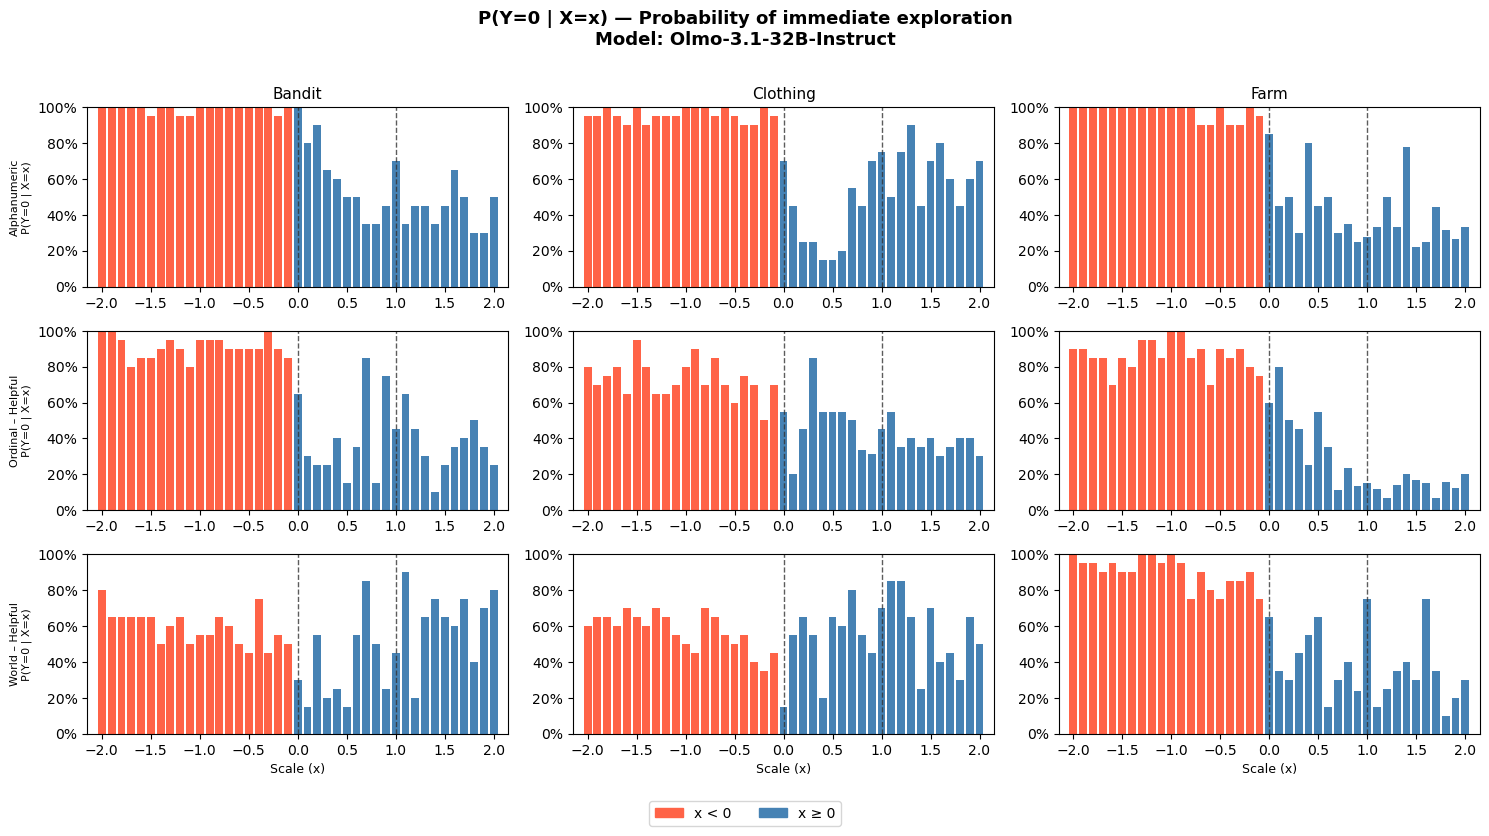

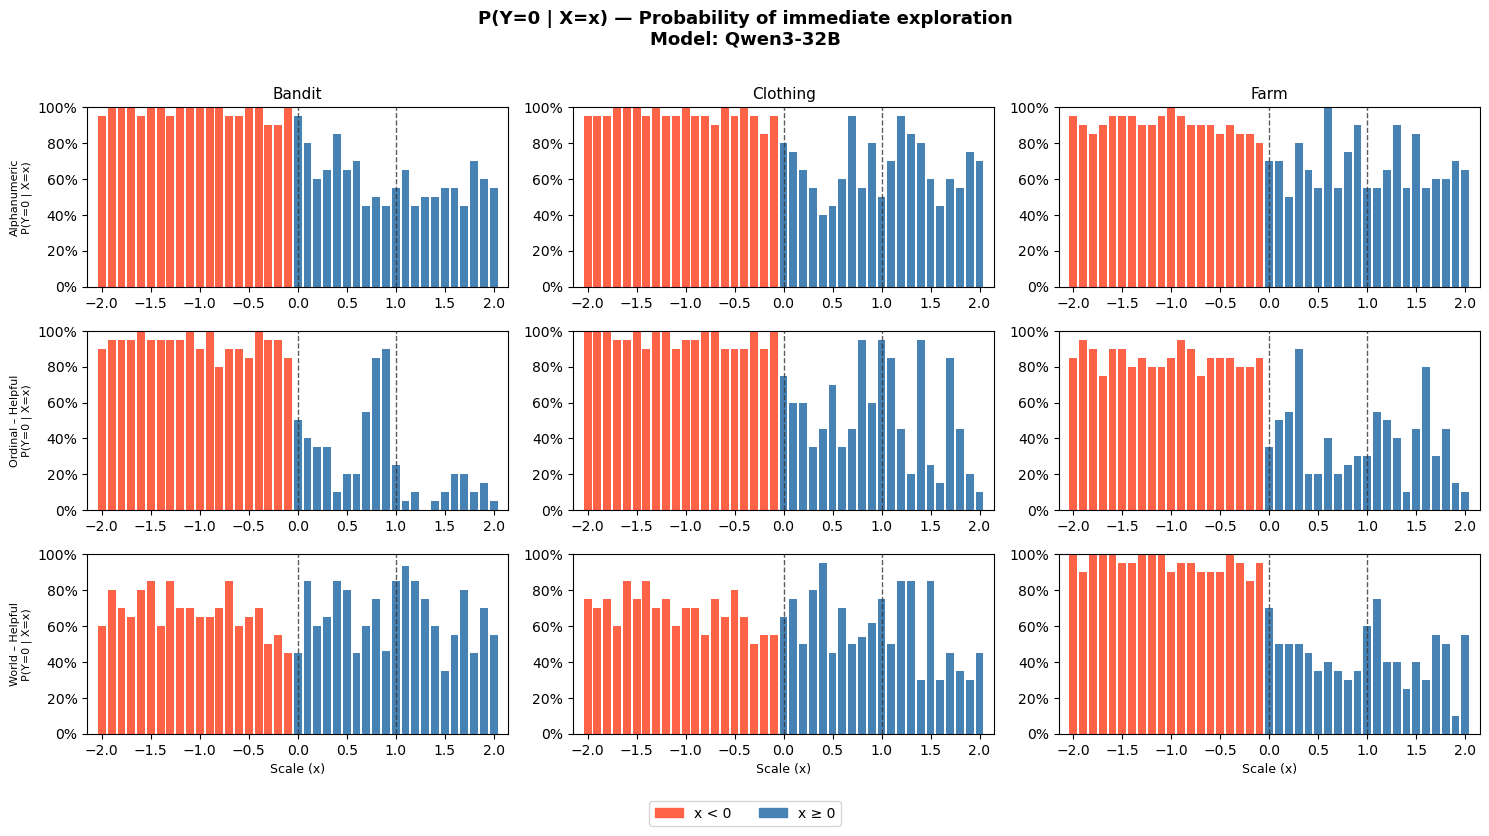

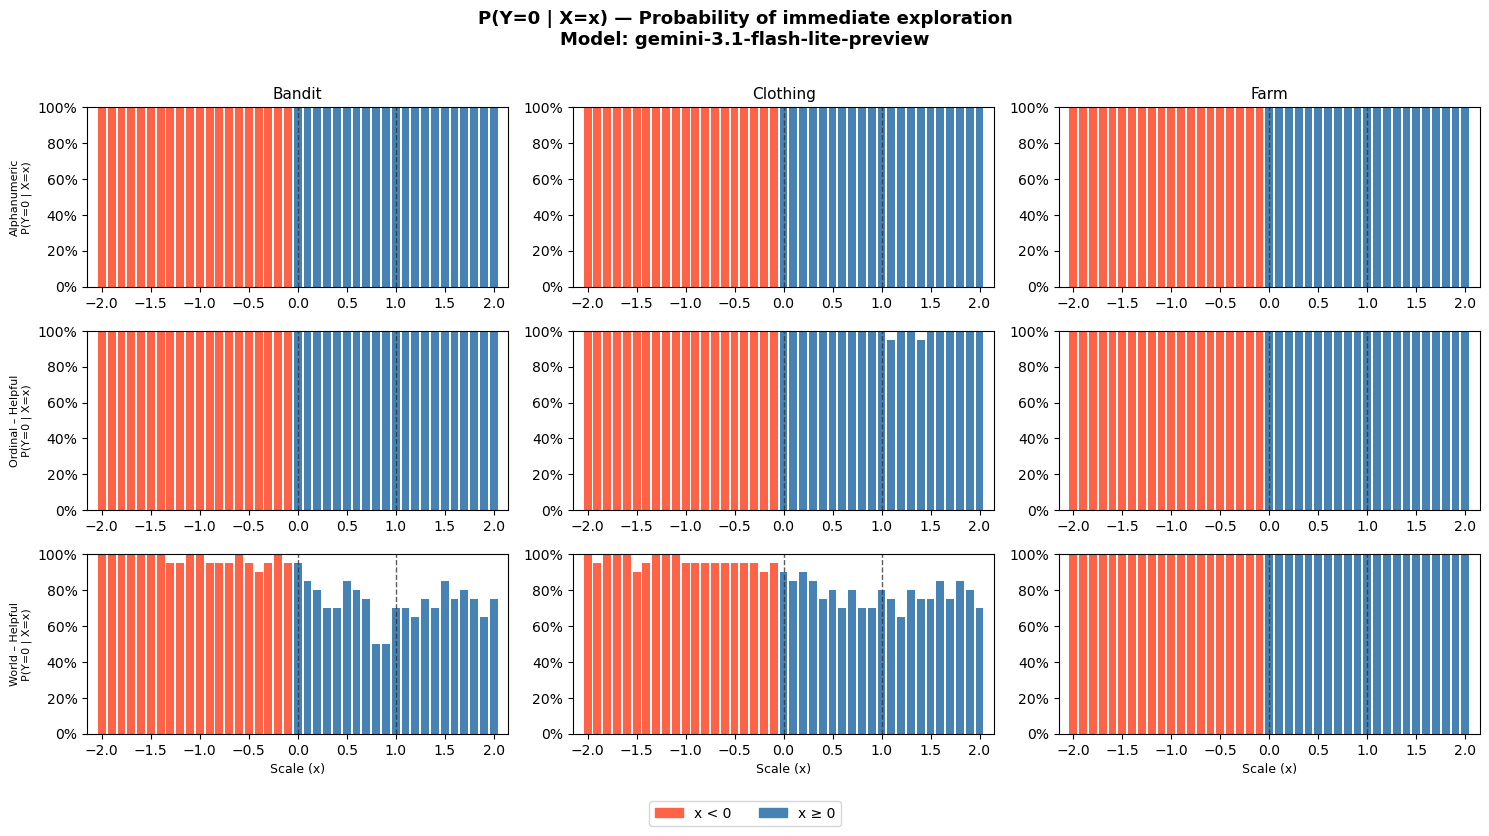

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models  = sorted(stats_agg['model'].unique())
domains = sorted(stats_agg['domain'].unique())

BAR_WIDTH   = 0.08
VLINE_COLOR = '#333333'

for model in models:
    nrows = len(NOMS_TO_PLOT)
    ncols = len(domains)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 2.8 * nrows), squeeze=False)

    for row_idx, nom in enumerate(NOMS_TO_PLOT):
        for col_idx, domain in enumerate(domains):
            ax = axes[row_idx, col_idx]
            sub = stats_agg[
                (stats_agg['model'] == model) &
                (stats_agg['domain'] == domain) &
                (stats_agg['nomenclature'] == nom)
            ].sort_values('scale')

            if sub.empty:
                ax.set_visible(False)
                continue

            scales = sub['scale'].values
            values = sub['P_Y0'].values
            colors = ['tomato' if s < 0 else 'steelblue' for s in scales]

            ax.bar(scales, values, width=BAR_WIDTH, color=colors, edgecolor='none')
            ax.axvline(x=0,   color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
            ax.axvline(x=1.0, color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
            ax.set_ylim(0, 1)
            ax.set_xlim(-2.15, 2.15)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

            if row_idx == 0:
                ax.set_title(domain, fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(f"{NOM_LABELS[nom]}\nP(Y=0 | X=x)", fontsize=8)
            if row_idx == nrows - 1:
                ax.set_xlabel("Scale (x)", fontsize=9)

    red_patch  = mpatches.Patch(color='tomato',    label='x < 0')
    blue_patch = mpatches.Patch(color='steelblue', label='x \u2265 0')
    fig.legend(
        handles=[red_patch, blue_patch],
        loc='lower center', bbox_to_anchor=(0.5, 0.0),
        ncol=2, fontsize=10, frameon=True,
    )
    fig.suptitle(
        f"P(Y=0 | X=x) \u2014 Probability of immediate exploration\nModel: {model}",
        fontsize=13, fontweight='bold',
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()


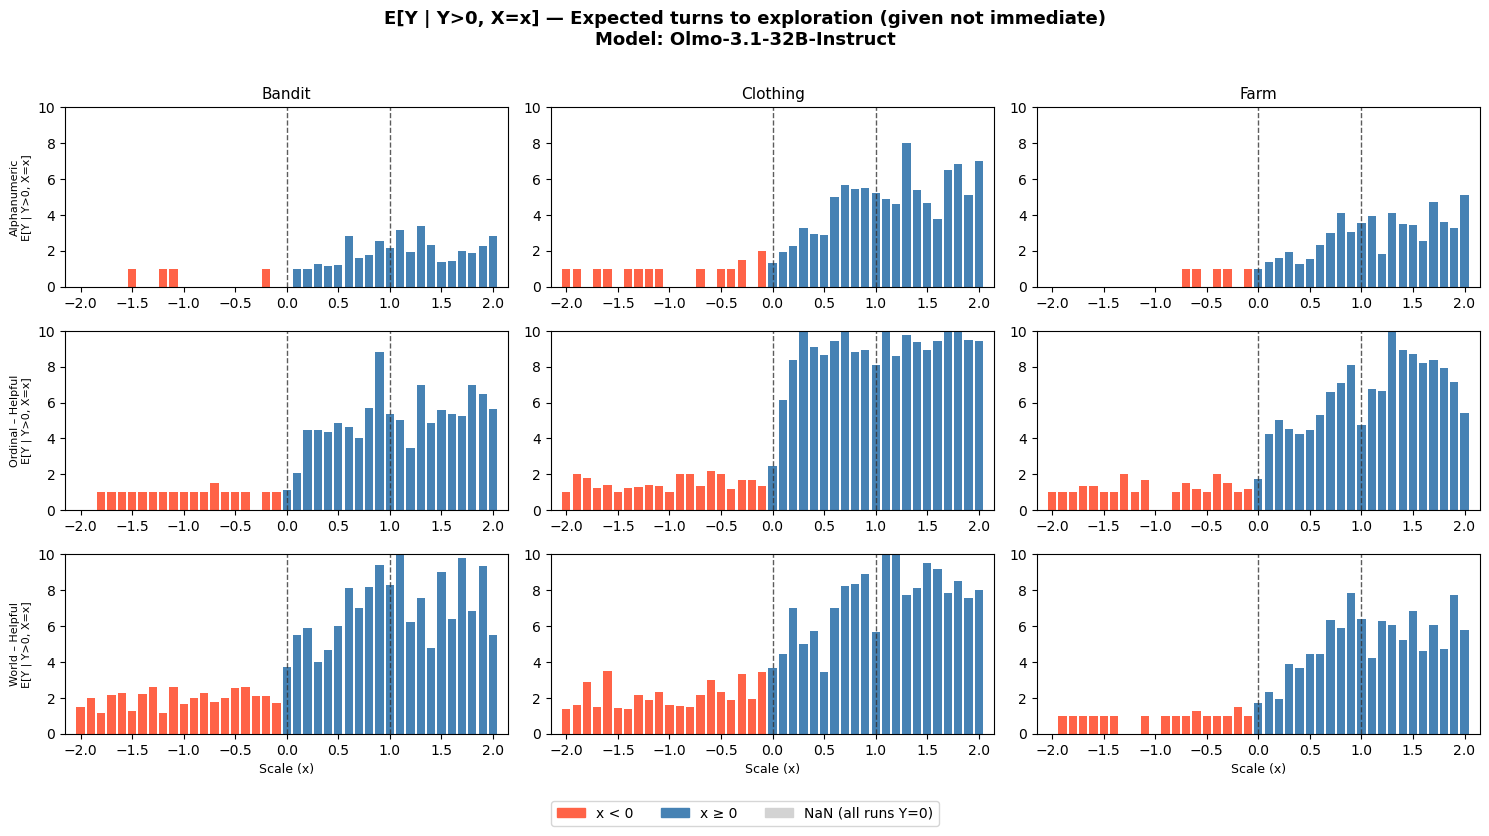

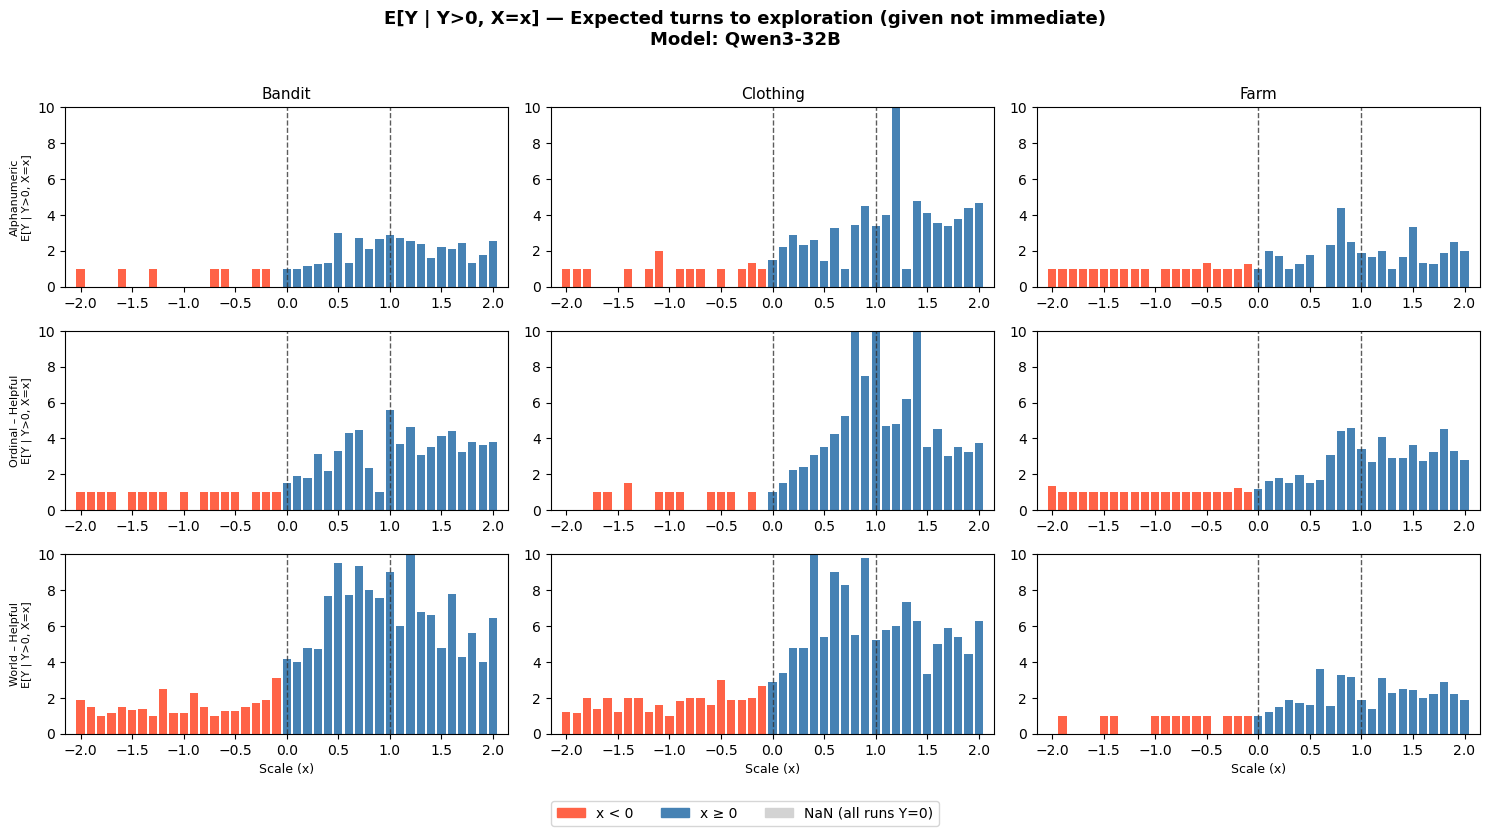

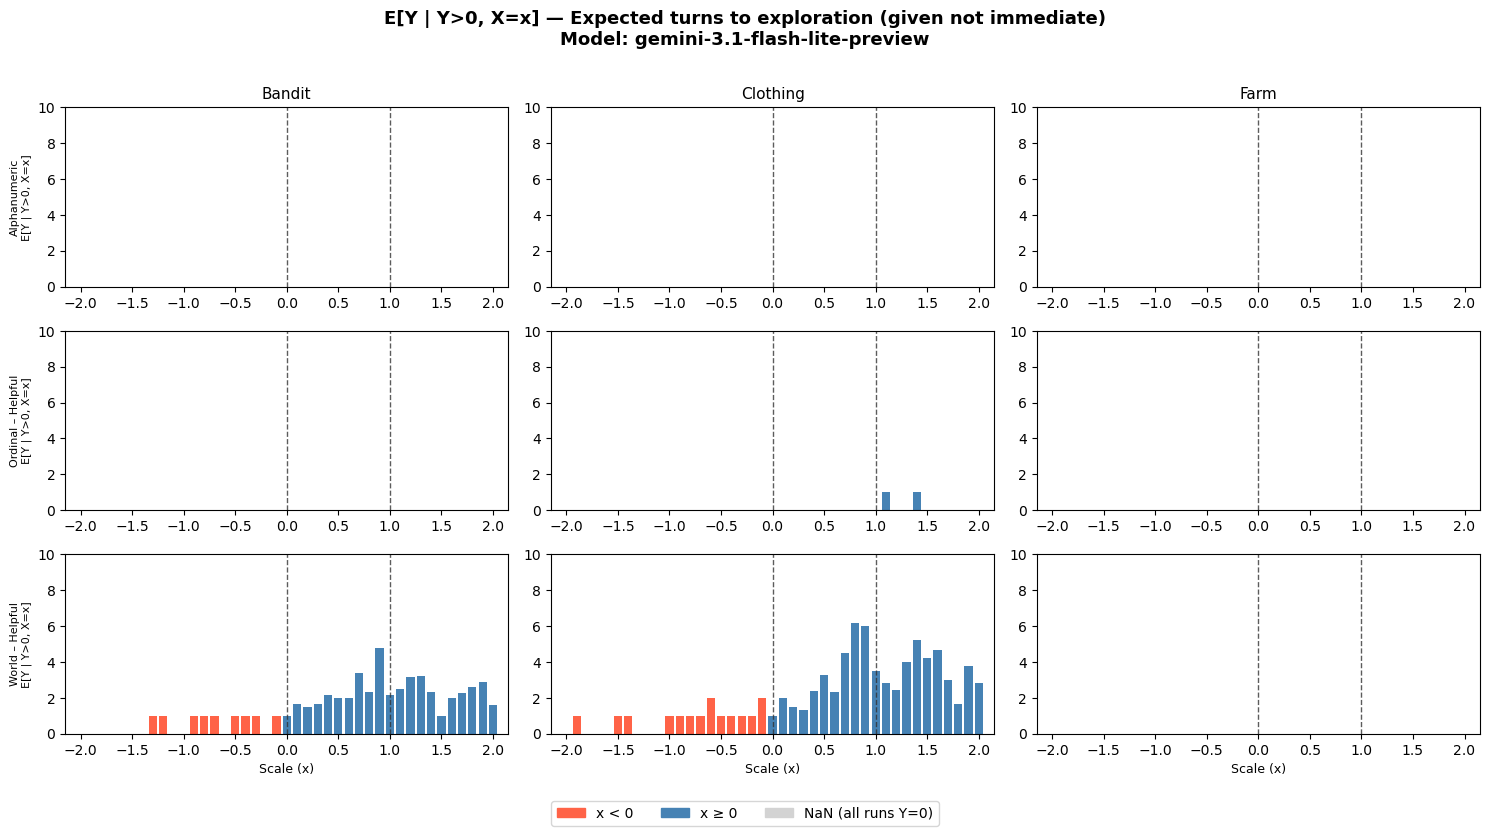

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models  = sorted(stats_agg['model'].unique())
domains = sorted(stats_agg['domain'].unique())

BAR_WIDTH   = 0.08
VLINE_COLOR = '#333333'

for model in models:
    nrows = len(NOMS_TO_PLOT)
    ncols = len(domains)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 2.8 * nrows), squeeze=False)

    for row_idx, nom in enumerate(NOMS_TO_PLOT):
        for col_idx, domain in enumerate(domains):
            ax = axes[row_idx, col_idx]
            sub = stats_agg[
                (stats_agg['model'] == model) &
                (stats_agg['domain'] == domain) &
                (stats_agg['nomenclature'] == nom)
            ].sort_values('scale')

            if sub.empty:
                ax.set_visible(False)
                continue

            scales = sub['scale'].values
            values = sub['E_Y_pos'].values   # may contain NaN

            colors = [
                'lightgrey' if np.isnan(v) else ('tomato' if s < 0 else 'steelblue')
                for s, v in zip(scales, values)
            ]
            bar_heights = np.where(np.isnan(values), 0.0, values)

            ax.bar(scales, bar_heights, width=BAR_WIDTH, color=colors, edgecolor='none')
            ax.axvline(x=0,   color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
            ax.axvline(x=1.0, color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
            ax.set_xlim(-2.15, 2.15)
            ax.set_ylim(0, 10)

            if row_idx == 0:
                ax.set_title(domain, fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(f"{NOM_LABELS[nom]}\nE[Y | Y>0, X=x]", fontsize=8)
            if row_idx == nrows - 1:
                ax.set_xlabel("Scale (x)", fontsize=9)

    red_patch  = mpatches.Patch(color='tomato',    label='x < 0')
    blue_patch = mpatches.Patch(color='steelblue', label='x \u2265 0')
    grey_patch = mpatches.Patch(color='lightgrey', label='NaN (all runs Y=0)')
    fig.legend(
        handles=[red_patch, blue_patch, grey_patch],
        loc='lower center', bbox_to_anchor=(0.5, 0.0),
        ncol=3, fontsize=10, frameon=True,
    )
    fig.suptitle(
        f"E[Y | Y>0, X=x] \u2014 Expected turns to exploration (given not immediate)\nModel: {model}",
        fontsize=13, fontweight='bold',
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()


In [11]:
import os
import pandas as pd

# Tidy summary table: one row per (model, domain, nomenclature, scale)
table_df = (
    stats_agg[['model', 'domain', 'nomenclature', 'scale', 'P_Y0', 'E_Y_pos', 'N_pos', 'N_total']]
    .rename(columns={
        'P_Y0':    'P(Y=0)',
        'E_Y_pos': 'E[Y|Y>0]',
        'N_pos':   'N_conditional',
    })
    .sort_values(['model', 'domain', 'nomenclature', 'scale'])
    .reset_index(drop=True)
)

# CSV export
csv_path = "experiments/scale_sweep_py0_eypos_summary.csv"
table_df.to_csv(csv_path, index=False, float_format="%.4f")
print(f"Saved CSV → {csv_path}  (shape: {table_df.shape})")
print(table_df.head(12).to_string(index=False))

# LaTeX export
latex_path = "experiments/scale_sweep_py0_eypos_summary.tex"
latex_str = table_df.to_latex(
    index=False,
    float_format="%.4f",
    na_rep="---",
    caption="P(Y=0 | X=x) and E[Y | Y>0, X=x] summary across models, domains, nomenclatures, and scale values.",
    label="tab:scale_sweep_py0_eypos",
    column_format="llllrrrr",
)
with open(latex_path, "w") as f:
    f.write(latex_str)
print(f"\nSaved LaTeX → {latex_path}")
print("\n--- LaTeX (first 40 lines) ---")
print("\n".join(latex_str.splitlines()[:40]))


Saved CSV → experiments/scale_sweep_py0_eypos_summary.csv  (shape: (1107, 8))
                model domain nomenclature  scale  P(Y=0)  E[Y|Y>0]  N_conditional  N_total
Olmo-3.1-32B-Instruct Bandit alphanumeric   -2.0    1.00       NaN            0.0     20.0
Olmo-3.1-32B-Instruct Bandit alphanumeric   -1.9    1.00       NaN            0.0     20.0
Olmo-3.1-32B-Instruct Bandit alphanumeric   -1.8    1.00       NaN            0.0     20.0
Olmo-3.1-32B-Instruct Bandit alphanumeric   -1.7    1.00       NaN            0.0     20.0
Olmo-3.1-32B-Instruct Bandit alphanumeric   -1.6    1.00       NaN            0.0     20.0
Olmo-3.1-32B-Instruct Bandit alphanumeric   -1.5    0.95       1.0            1.0     20.0
Olmo-3.1-32B-Instruct Bandit alphanumeric   -1.4    1.00       NaN            0.0     20.0
Olmo-3.1-32B-Instruct Bandit alphanumeric   -1.3    1.00       NaN            0.0     20.0
Olmo-3.1-32B-Instruct Bandit alphanumeric   -1.2    0.95       1.0            1.0     20.0
Olmo-3.1-32B

## P(Y=0 | X=x) and E[Y | Y>0, X=x] — Ordinal Helpful, all models
Same bar plots as above but restricted to `ordinal_helpful`; rows = model, columns = domain.

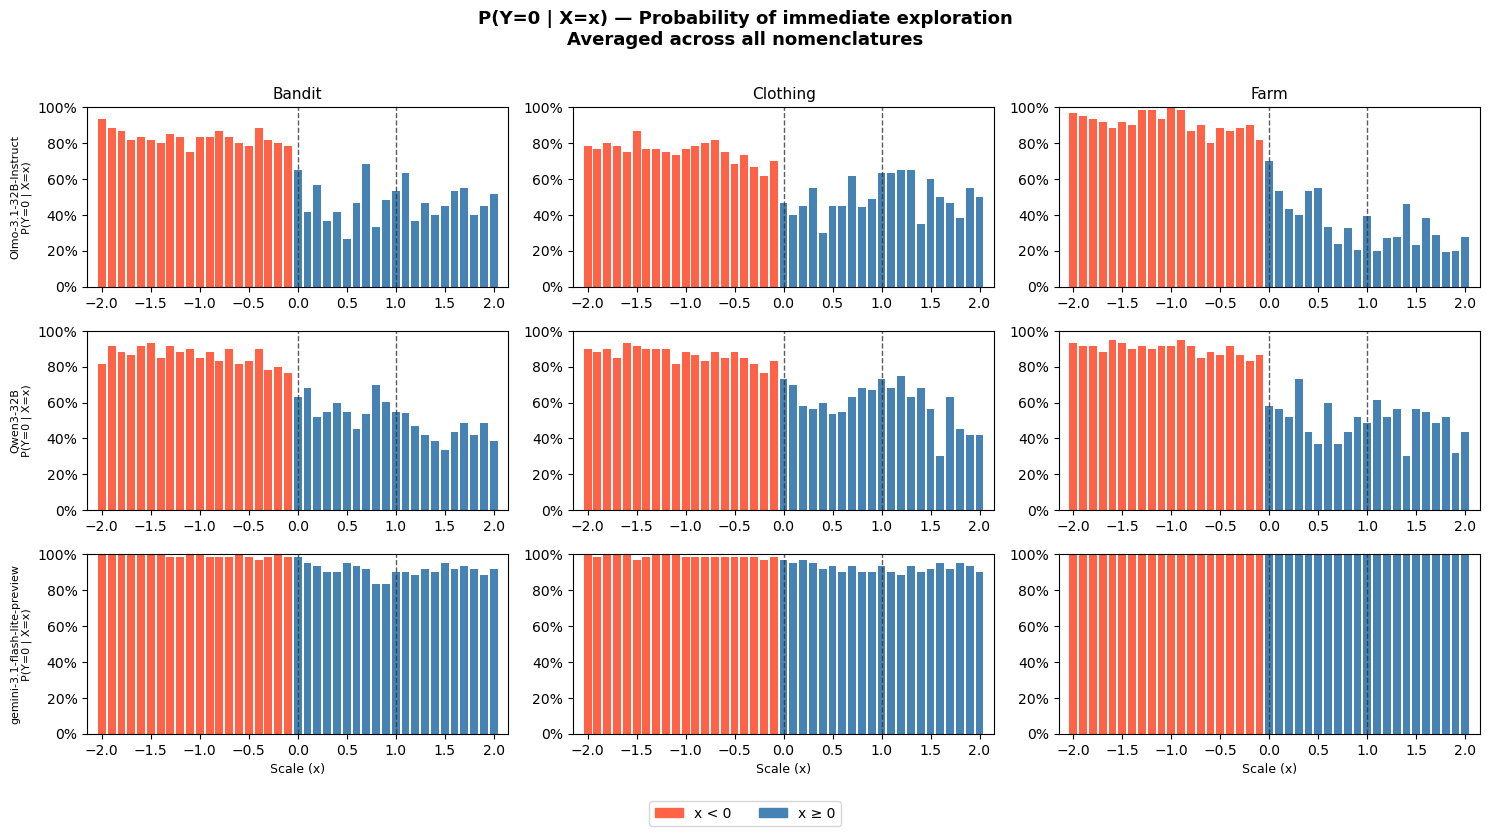

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Average P_Y0 across all nomenclatures for each (model, domain, scale)
_sub = (
    stats_agg
    .groupby(['model', 'domain', 'scale'], as_index=False)
    .agg(P_Y0=('P_Y0', 'mean'))
)
models  = sorted(_sub['model'].unique())
domains = sorted(_sub['domain'].unique())

BAR_WIDTH   = 0.08
VLINE_COLOR = '#333333'

nrows = len(models)
ncols = len(domains)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 2.8 * nrows), squeeze=False)

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = _sub[
            (_sub['model'] == model) &
            (_sub['domain'] == domain)
        ].sort_values('scale')

        if sub.empty:
            ax.set_visible(False)
            continue

        scales = sub['scale'].values
        values = sub['P_Y0'].values
        colors = ['tomato' if s < 0 else 'steelblue' for s in scales]

        ax.bar(scales, values, width=BAR_WIDTH, color=colors, edgecolor='none')
        ax.axvline(x=0,   color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
        ax.axvline(x=1.0, color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0, 1)
        ax.set_xlim(-2.15, 2.15)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nP(Y=0 | X=x)", fontsize=8)
        if row_idx == nrows - 1:
            ax.set_xlabel("Scale (x)", fontsize=9)

red_patch  = mpatches.Patch(color='tomato',    label='x < 0')
blue_patch = mpatches.Patch(color='steelblue', label='x \u2265 0')
fig.legend(
    handles=[red_patch, blue_patch],
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=2, fontsize=10, frameon=True,
)
fig.suptitle(
    "P(Y=0 | X=x) \u2014 Probability of immediate exploration\nAveraged across all nomenclatures",
    fontsize=13, fontweight='bold',
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

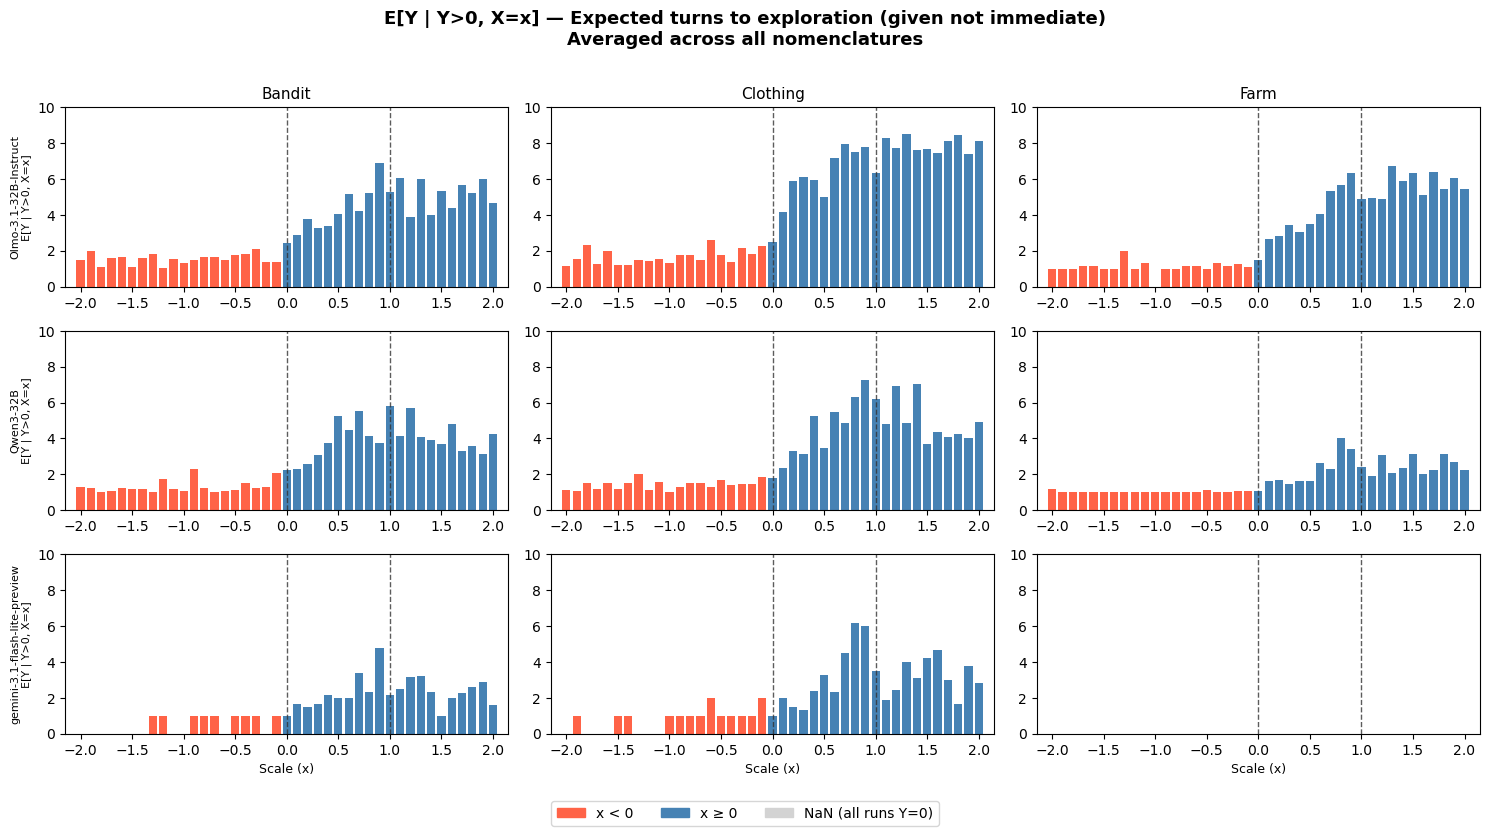

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Average E_Y_pos across all nomenclatures for each (model, domain, scale)
_sub = (
    stats_agg
    .groupby(['model', 'domain', 'scale'], as_index=False)
    .agg(E_Y_pos=('E_Y_pos', 'mean'))
)
models  = sorted(_sub['model'].unique())
domains = sorted(_sub['domain'].unique())

BAR_WIDTH   = 0.08
VLINE_COLOR = '#333333'

nrows = len(models)
ncols = len(domains)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 2.8 * nrows), squeeze=False)

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        ax = axes[row_idx, col_idx]
        sub = _sub[
            (_sub['model'] == model) &
            (_sub['domain'] == domain)
        ].sort_values('scale')

        if sub.empty:
            ax.set_visible(False)
            continue

        scales = sub['scale'].values
        values = sub['E_Y_pos'].values   # may contain NaN

        colors = [
            'lightgrey' if np.isnan(v) else ('tomato' if s < 0 else 'steelblue')
            for s, v in zip(scales, values)
        ]
        bar_heights = np.where(np.isnan(values), 0.0, values)

        ax.bar(scales, bar_heights, width=BAR_WIDTH, color=colors, edgecolor='none')
        ax.axvline(x=0,   color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
        ax.axvline(x=1.0, color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_xlim(-2.15, 2.15)
        ax.set_ylim(0, 10)

        if row_idx == 0:
            ax.set_title(domain, fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"{model}\nE[Y | Y>0, X=x]", fontsize=8)
        if row_idx == nrows - 1:
            ax.set_xlabel("Scale (x)", fontsize=9)

red_patch  = mpatches.Patch(color='tomato',    label='x < 0')
blue_patch = mpatches.Patch(color='steelblue', label='x \u2265 0')
grey_patch = mpatches.Patch(color='lightgrey', label='NaN (all runs Y=0)')
fig.legend(
    handles=[red_patch, blue_patch, grey_patch],
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=3, fontsize=10, frameon=True,
)
fig.suptitle(
    "E[Y | Y>0, X=x] \u2014 Expected turns to exploration (given not immediate)\nAveraged across all nomenclatures",
    fontsize=13, fontweight='bold',
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

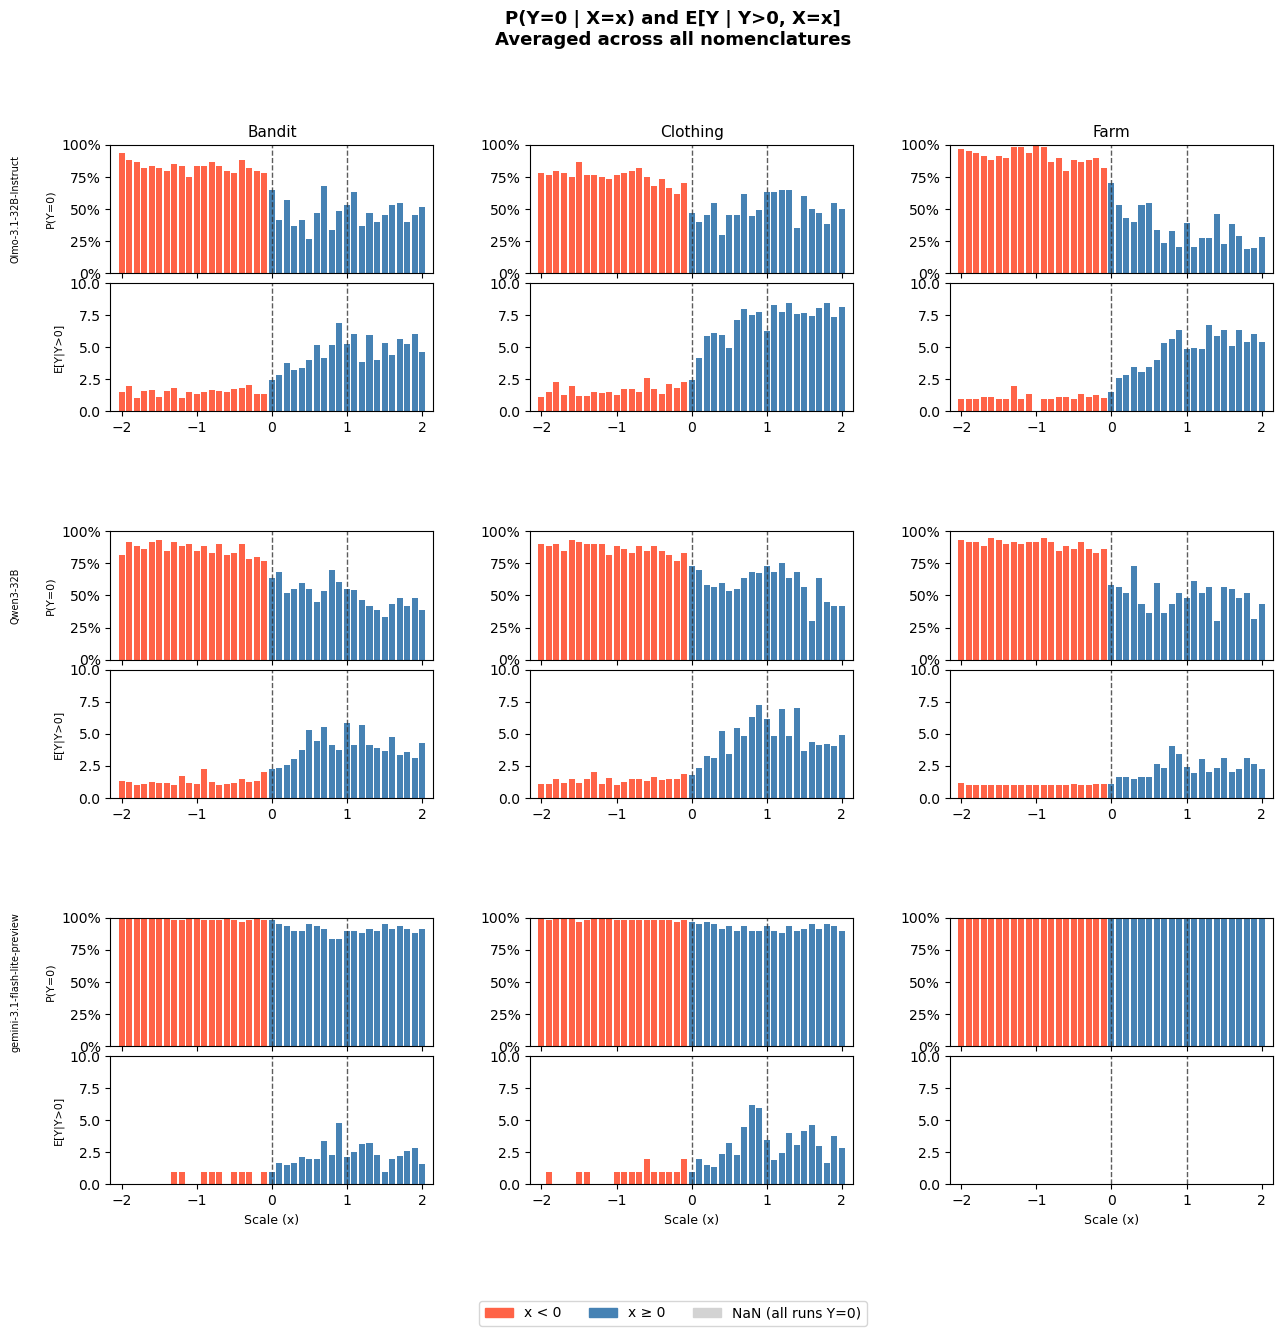

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# Average both metrics across all nomenclatures for each (model, domain, scale)
_sub = (
    stats_agg
    .groupby(['model', 'domain', 'scale'], as_index=False)
    .agg(P_Y0=('P_Y0', 'mean'), E_Y_pos=('E_Y_pos', 'mean'))
)
models  = sorted(_sub['model'].unique())
domains = sorted(_sub['domain'].unique())

BAR_WIDTH   = 0.08
VLINE_COLOR = '#333333'

nrows = len(models)
ncols = len(domains)

# Outer grid: one row per model, one col per domain
# Each cell is split into 2 sub-rows (top=P_Y0, bottom=E_Y_pos)
fig = plt.figure(figsize=(5 * ncols, 4.5 * nrows))
outer_gs = GridSpec(nrows, ncols, figure=fig, hspace=0.45, wspace=0.3)

for row_idx, model in enumerate(models):
    for col_idx, domain in enumerate(domains):
        inner_gs = GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer_gs[row_idx, col_idx],
            hspace=0.08,
        )
        ax_top = fig.add_subplot(inner_gs[0])
        ax_bot = fig.add_subplot(inner_gs[1], sharex=ax_top)

        sub = _sub[
            (_sub['model'] == model) &
            (_sub['domain'] == domain)
        ].sort_values('scale')

        if sub.empty:
            ax_top.set_visible(False)
            ax_bot.set_visible(False)
            continue

        scales = sub['scale'].values
        py0    = sub['P_Y0'].values
        eypos  = sub['E_Y_pos'].values

        colors_py0  = ['tomato' if s < 0 else 'steelblue' for s in scales]
        colors_eypos = [
            'lightgrey' if np.isnan(v) else ('tomato' if s < 0 else 'steelblue')
            for s, v in zip(scales, eypos)
        ]
        bar_eypos = np.where(np.isnan(eypos), 0.0, eypos)

        # ── Top: P(Y=0) ──
        ax_top.bar(scales, py0, width=BAR_WIDTH, color=colors_py0, edgecolor='none')
        ax_top.axvline(x=0,   color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
        ax_top.axvline(x=1.0, color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
        ax_top.set_ylim(0, 1)
        ax_top.set_xlim(-2.15, 2.15)
        ax_top.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
        ax_top.tick_params(labelbottom=False)

        # ── Bottom: E[Y | Y>0] ──
        ax_bot.bar(scales, bar_eypos, width=BAR_WIDTH, color=colors_eypos, edgecolor='none')
        ax_bot.axvline(x=0,   color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
        ax_bot.axvline(x=1.0, color=VLINE_COLOR, linestyle='--', linewidth=1.0, alpha=0.8)
        ax_bot.set_xlim(-2.15, 2.15)
        ax_bot.set_ylim(0, 10)

        # Titles and labels
        if row_idx == 0:
            ax_top.set_title(domain, fontsize=11, pad=6)
        if col_idx == 0:
            ax_top.set_ylabel("P(Y=0)", fontsize=8)
            ax_bot.set_ylabel("E[Y|Y>0]", fontsize=8)
        if row_idx == nrows - 1:
            ax_bot.set_xlabel("Scale (x)", fontsize=9)

        # Model label on left side spanning both sub-rows
        if col_idx == 0:
            mid_y = 0.5
            ax_top.annotate(
                model, xy=(-0.28, mid_y), xycoords='axes fraction',
                ha='right', va='center', fontsize=7, rotation=90,
                annotation_clip=False,
            )

red_patch  = mpatches.Patch(color='tomato',    label='x < 0')
blue_patch = mpatches.Patch(color='steelblue', label='x \u2265 0')
grey_patch = mpatches.Patch(color='lightgrey', label='NaN (all runs Y=0)')
fig.legend(
    handles=[red_patch, blue_patch, grey_patch],
    loc='lower center', bbox_to_anchor=(0.5, 0.0),
    ncol=3, fontsize=10, frameon=True,
)
fig.suptitle(
    "P(Y=0 | X=x) and E[Y | Y>0, X=x]\nAveraged across all nomenclatures",
    fontsize=13, fontweight='bold',
)
plt.show()

## Heatmaps

/var/folders/b6/875pzbr94hj63w2l6qgx1cpw0000gn/T/ipykernel_97530/2741974113.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


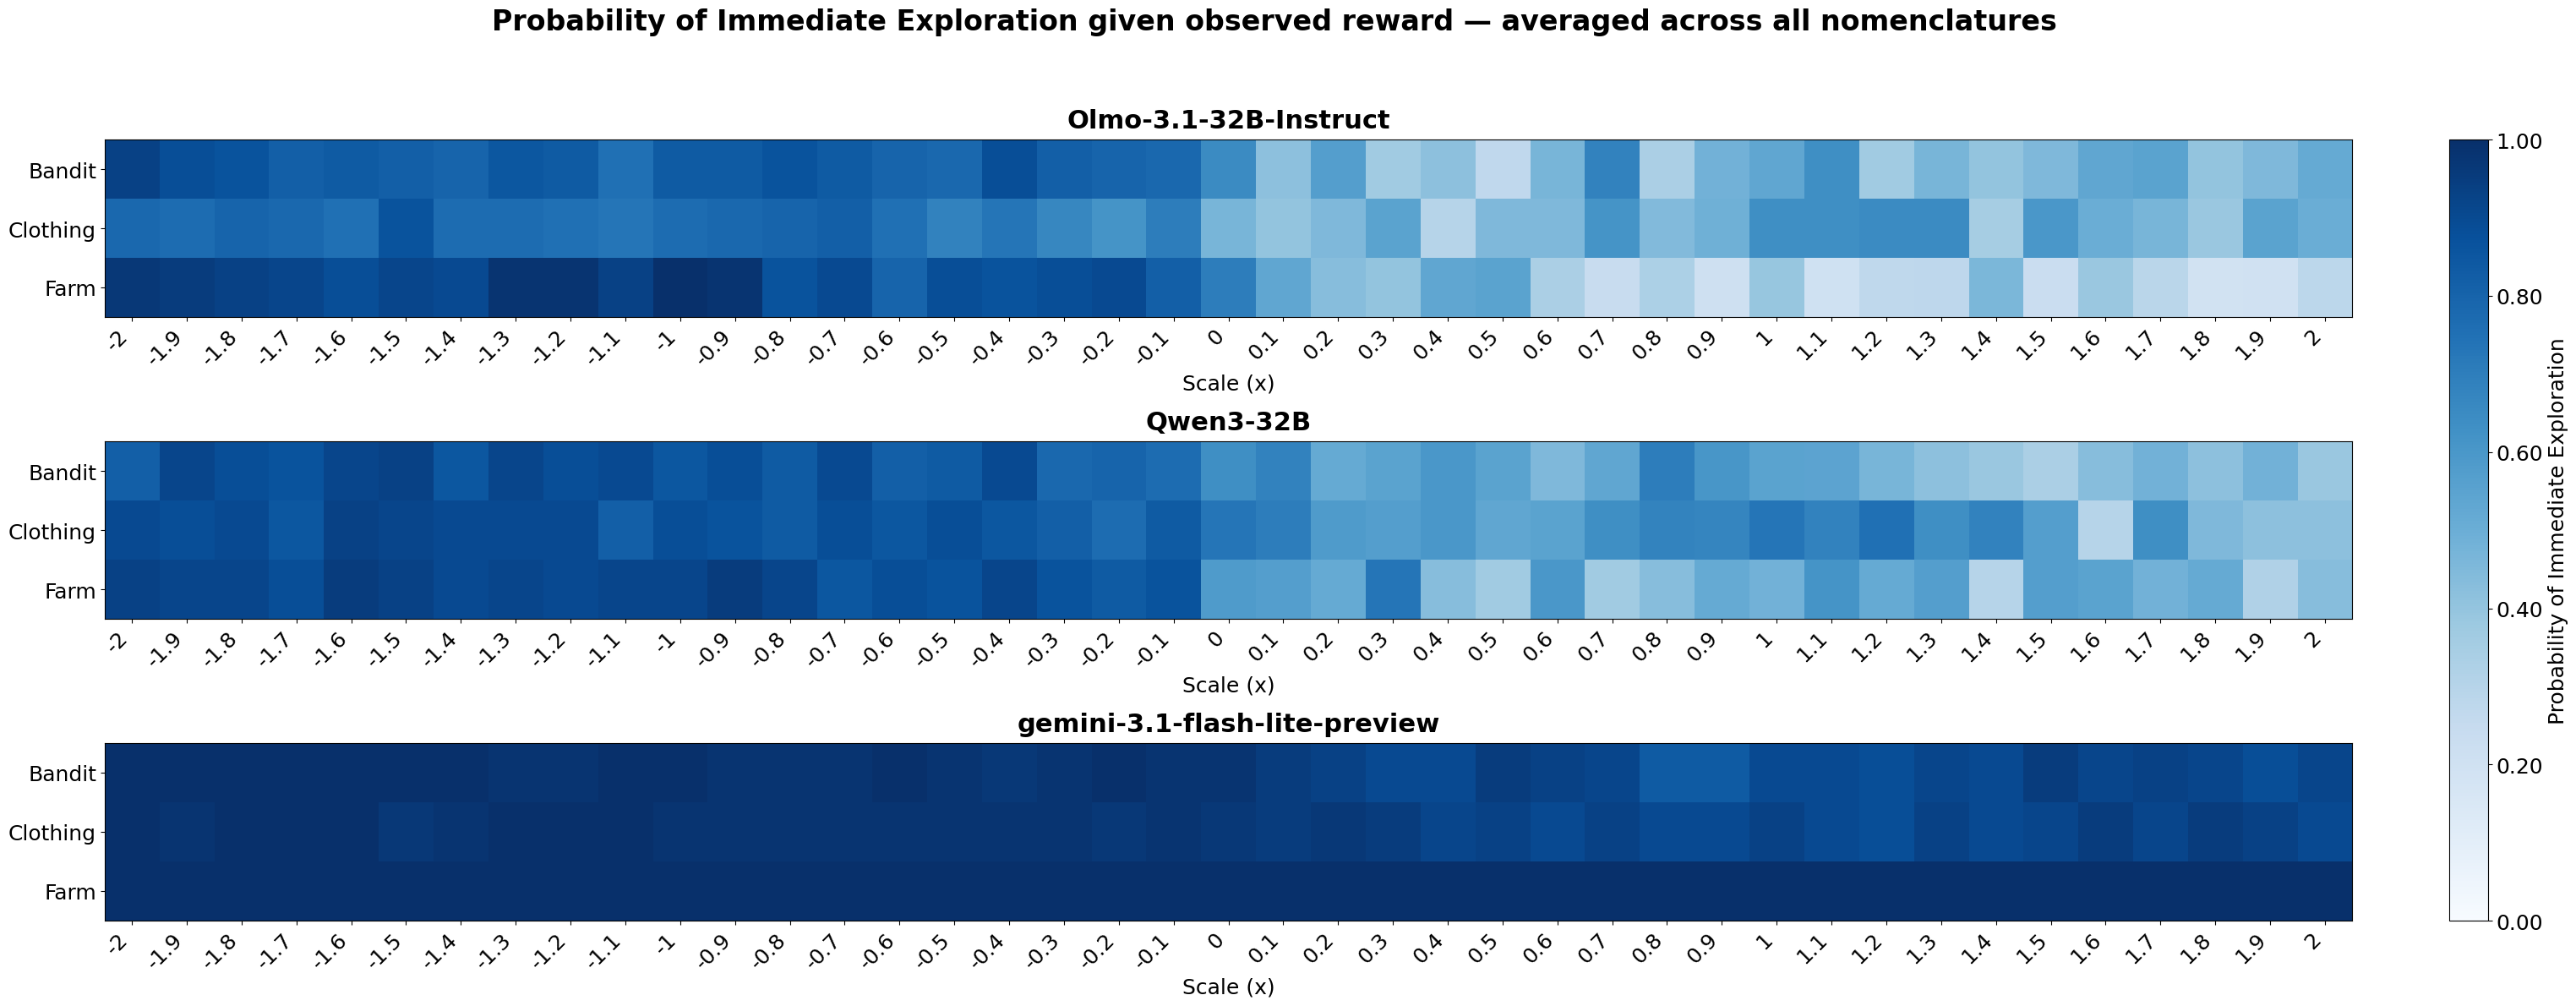

/var/folders/b6/875pzbr94hj63w2l6qgx1cpw0000gn/T/ipykernel_97530/2741974113.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


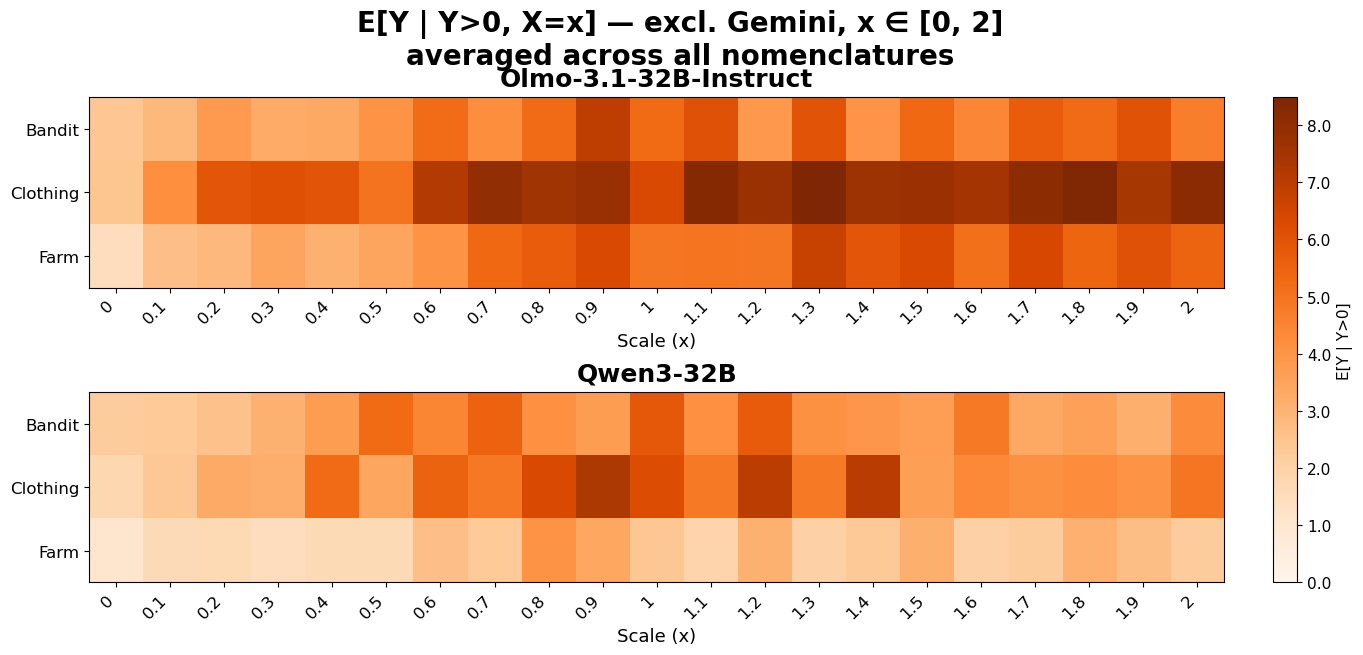

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PY0_LABEL_FONTSIZE  = 18
PY0_TICK_FONTSIZE   = 18
PY0_TITLE_FONTSIZE  = 22
PY0_CBAR_FONTSIZE   = 18

EY_LABEL_FONTSIZE   = 13
EY_TICK_FONTSIZE    = 12
EY_TITLE_FONTSIZE   = 18
EY_CBAR_FONTSIZE    = 11

# Average both metrics across all nomenclatures
_sub = (
    stats_agg
    .groupby(['model', 'domain', 'scale'], as_index=False)
    .agg(P_Y0=('P_Y0', 'mean'), E_Y_pos=('E_Y_pos', 'mean'))
)

domains = sorted(_sub['domain'].unique())

_sub_py0 = _sub.copy()
_sub_ey  = _sub[
    (~_sub['model'].str.contains('gemini', case=False)) &
    (_sub['scale'] >= 0) & (_sub['scale'] <= 2.0)
].copy()

models_py0 = sorted(_sub_py0['model'].unique())
models_ey  = sorted(_sub_ey['model'].unique())
scales_py0 = sorted(_sub_py0['scale'].unique())
scales_ey  = sorted(_sub_ey['scale'].unique())

def build_matrix(data, model, col_scales, metric):
    mat = np.full((len(domains), len(col_scales)), np.nan)
    for r, domain in enumerate(domains):
        for c, scale in enumerate(col_scales):
            val = data.loc[
                (data['model'] == model) & (data['domain'] == domain) & (data['scale'] == scale),
                metric
            ]
            if not val.empty:
                mat[r, c] = val.values[0]
    return mat

# ── Figure 1: P(Y=0) — one subplot per model ──
fig1, axes1 = plt.subplots(
    len(models_py0), 1,
    figsize=(max(8, len(scales_py0) * 0.9), len(models_py0) * (len(domains) * 0.8 + 1.6)),
    gridspec_kw={'hspace': 0.7},
)
if len(models_py0) == 1:
    axes1 = [axes1]

last_im1 = None
for ax, model in zip(axes1, models_py0):
    mat = build_matrix(_sub_py0, model, scales_py0, 'P_Y0')
    last_im1 = ax.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(len(scales_py0)))
    ax.set_xticklabels([f"{s:.2g}" for s in scales_py0], fontsize=PY0_TICK_FONTSIZE, rotation=45, ha='right')
    ax.set_yticks(range(len(domains)))
    ax.set_yticklabels(domains, fontsize=PY0_TICK_FONTSIZE)
    ax.set_xlabel("Scale (x)", fontsize=PY0_LABEL_FONTSIZE)
    ax.set_title(model, fontsize=PY0_TITLE_FONTSIZE, fontweight='bold', pad=10)

cbar1 = fig1.colorbar(last_im1, ax=axes1, fraction=0.03, pad=0.04, format='%.2f')
cbar1.ax.tick_params(labelsize=PY0_CBAR_FONTSIZE)
cbar1.set_label("Probability of Immediate Exploration", fontsize=PY0_CBAR_FONTSIZE)

fig1.suptitle("Probability of Immediate Exploration given observed reward — averaged across all nomenclatures", fontsize=PY0_TITLE_FONTSIZE + 2, fontweight='bold', y=1.01)
plt.savefig(f"figures/main/scalesweep_py0.pdf",     dpi=300, bbox_inches='tight')
plt.savefig(f"figures_png/main/scalesweep_py0.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# ── Figure 2: E[Y | Y>0] — one subplot per model, no Gemini, x in [0,2] ──
fig2, axes2 = plt.subplots(
    len(models_ey), 1,
    figsize=(max(6, len(scales_ey) * 0.75), len(models_ey) * (len(domains) * 0.65 + 1.2)),
    gridspec_kw={'hspace': 0.55},
)
if len(models_ey) == 1:
    axes2 = [axes2]

all_mats_ey = [build_matrix(_sub_ey, m, scales_ey, 'E_Y_pos') for m in models_ey]
vmax_ey = max((np.nanmax(m) for m in all_mats_ey if not np.all(np.isnan(m))), default=10)

last_im2 = None
for ax, model, mat in zip(axes2, models_ey, all_mats_ey):
    last_im2 = ax.imshow(mat, aspect='auto', cmap='Oranges', vmin=0, vmax=vmax_ey, interpolation='nearest')
    ax.set_xticks(range(len(scales_ey)))
    ax.set_xticklabels([f"{s:.2g}" for s in scales_ey], fontsize=EY_TICK_FONTSIZE, rotation=45, ha='right')
    ax.set_yticks(range(len(domains)))
    ax.set_yticklabels(domains, fontsize=EY_TICK_FONTSIZE)
    ax.set_xlabel("Scale (x)", fontsize=EY_LABEL_FONTSIZE)
    ax.set_title(model, fontsize=EY_TITLE_FONTSIZE, fontweight='bold', pad=8)

cbar2 = fig2.colorbar(last_im2, ax=axes2, fraction=0.03, pad=0.04, format='%.1f')
cbar2.ax.tick_params(labelsize=EY_CBAR_FONTSIZE)
cbar2.set_label("E[Y | Y>0]", fontsize=EY_CBAR_FONTSIZE)

fig2.suptitle("E[Y | Y>0, X=x] — excl. Gemini, x \u2208 [0, 2]\naveraged across all nomenclatures", fontsize=EY_TITLE_FONTSIZE + 2, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


/var/folders/b6/875pzbr94hj63w2l6qgx1cpw0000gn/T/ipykernel_97139/3452660412.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


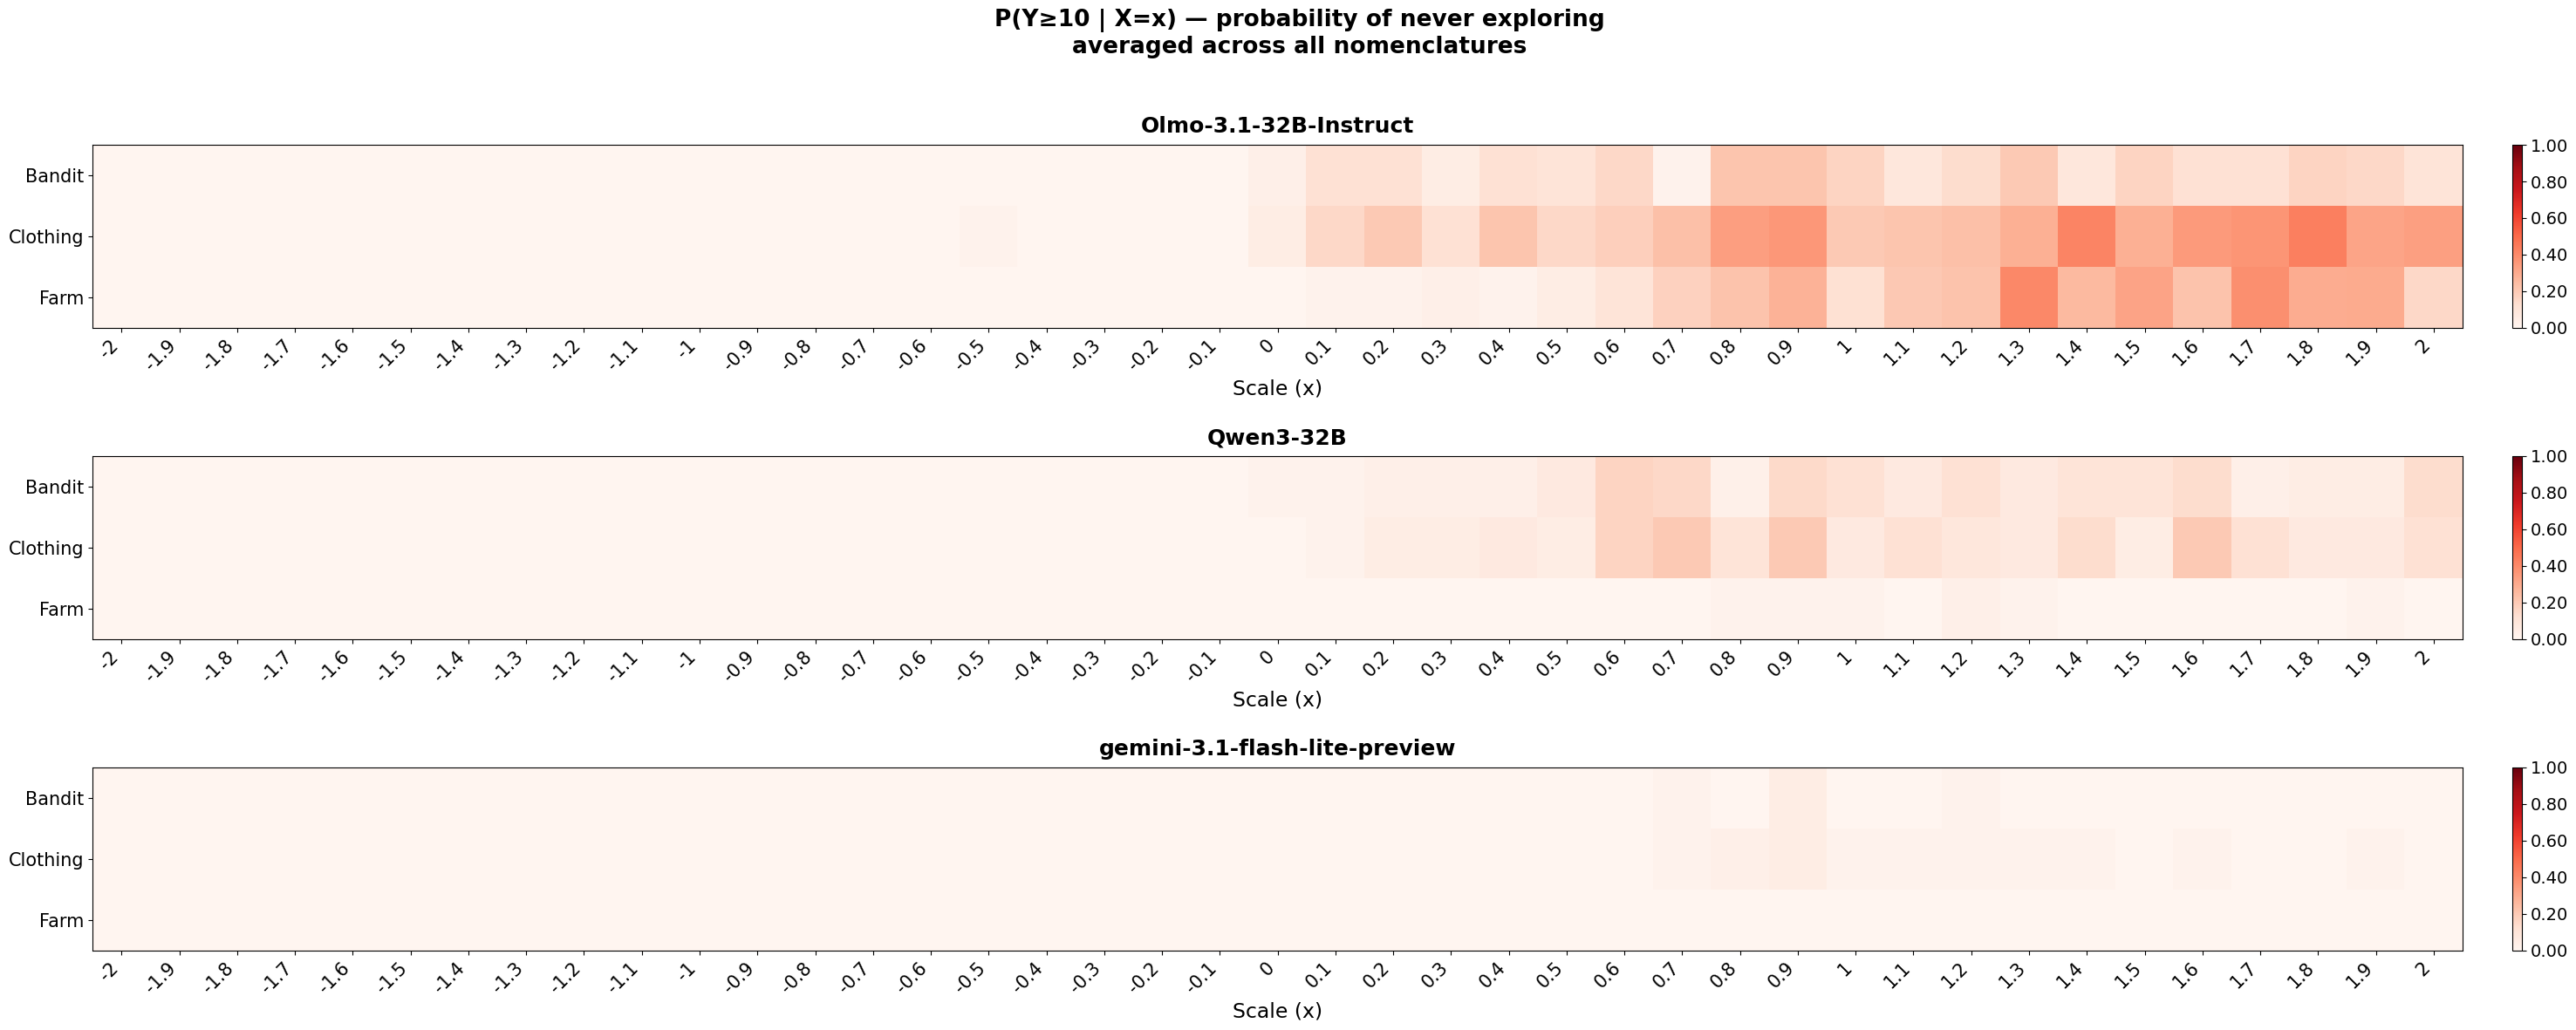

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PY10_LABEL_FONTSIZE = 17
PY10_TICK_FONTSIZE  = 15
PY10_TITLE_FONTSIZE = 18
PY10_CBAR_FONTSIZE  = 14

# Average P(Y>=10) across all nomenclatures
_sub_py10 = (
    stats_agg
    .groupby(['model', 'domain', 'scale'], as_index=False)
    .agg(P_Y10=('P_Y10', 'mean'))
)

models_py10 = sorted(_sub_py10['model'].unique())
scales_py10 = sorted(_sub_py10['scale'].unique())
domains     = sorted(_sub_py10['domain'].unique())

def build_matrix_py10(model):
    mat = np.full((len(domains), len(scales_py10)), np.nan)
    for r, domain in enumerate(domains):
        for c, scale in enumerate(scales_py10):
            val = _sub_py10.loc[
                (_sub_py10['model'] == model) & (_sub_py10['domain'] == domain) & (_sub_py10['scale'] == scale),
                'P_Y10'
            ]
            if not val.empty:
                mat[r, c] = val.values[0]
    return mat

fig, axes = plt.subplots(
    len(models_py10), 1,
    figsize=(max(8, len(scales_py10) * 0.9), len(models_py10) * (len(domains) * 0.8 + 1.6)),
    gridspec_kw={'hspace': 0.7},
)
if len(models_py10) == 1:
    axes = [axes]

for ax, model in zip(axes, models_py10):
    mat = build_matrix_py10(model)
    im = ax.imshow(mat, aspect='auto', cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(len(scales_py10)))
    ax.set_xticklabels([f"{s:.2g}" for s in scales_py10], fontsize=PY10_TICK_FONTSIZE, rotation=45, ha='right')
    ax.set_yticks(range(len(domains)))
    ax.set_yticklabels(domains, fontsize=PY10_TICK_FONTSIZE)
    ax.set_xlabel("Scale (x)", fontsize=PY10_LABEL_FONTSIZE)
    ax.set_title(model, fontsize=PY10_TITLE_FONTSIZE, fontweight='bold', pad=10)
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, format='%.2f')
    cbar.ax.tick_params(labelsize=PY10_CBAR_FONTSIZE)

fig.suptitle("P(Y\u226510 | X=x) — probability of never exploring\naveraged across all nomenclatures",
             fontsize=PY10_TITLE_FONTSIZE + 1, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()